# T0 vs. Plasmid Analysis

Looking at gRNA behavior in the absence of drug.

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [2]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')


#-----load single amino-acid variants (SAVs) breakdown for each subpool------
SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

#------also load the raw editing for each (i.e. with compound mutations) -------

ABE1 = pd.read_csv('../../screening_data/04_editing/ABE_subpool1_HGVSp.zip')
CBE1 = pd.read_csv('../../screening_data/04_editing/CBE_subpool1_HGVSp.zip')
ABE2 = pd.read_csv('../../screening_data/04_editing/ABE_CDK12_13_HGVSp.zip')
CBE2 = pd.read_csv('../../screening_data/04_editing/CBE_CDK12_13_HGVSp.zip')

# Writing files for dbNFSP analysis

In [33]:
#HGVSp:Q8NH21:p.Gln17*

uniprot_ids = {'CDK7':'P50613',
               'CDK9':'P50750',
               'CDK8':'P49336',
               'CDK19':'Q9BWU1',
               'CDK12':'Q9NYV4',
               'CDK13':'Q14004',
               'CDK2':'P24941',
               'CDK4':'P11802',
               'CDK6':'Q00534'}

aa1_to_aa3 = {
    'A': 'Ala',
    'R': 'Arg',
    'N': 'Asn',
    'D': 'Asp',
    'C': 'Cys',
    'E': 'Glu',
    'Q': 'Gln',
    'G': 'Gly',
    'H': 'His',
    'I': 'Ile',
    'L': 'Leu',
    'K': 'Lys',
    'M': 'Met',
    'F': 'Phe',
    'P': 'Pro',
    'S': 'Ser',
    'T': 'Thr',
    'W': 'Trp',
    'Y': 'Tyr',
    'V': 'Val',
    '*': '*'   # Stop codon (optional)
}


genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

for gene in genes:
    #extract variants
    min_edit = 2

    print(f'{gene}: Chromosome = {np.unique(library[library["Gene"]==gene]["chrom"])[0]}')

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
        abe_vars = SAV_ABE1[(SAV_ABE1['Gene']==gene) & (SAV_ABE1['%Reads']>=min_edit) & (SAV_ABE1['HGVSp']!='WT')]
        cbe_vars = SAV_CBE1[(SAV_CBE1['Gene']==gene) & (SAV_CBE1['%Reads']>=min_edit) & (SAV_CBE1['HGVSp']!='WT')]
    elif gene in ['CDK12', 'CDK13']:
        abe_vars = SAV_ABE2[(SAV_ABE2['Gene']==gene) & (SAV_ABE2['%Reads']>=min_edit) & (SAV_ABE2['HGVSp']!='WT')]
        cbe_vars = SAV_CBE2[(SAV_CBE2['Gene']==gene) & (SAV_CBE2['%Reads']>=min_edit) & (SAV_CBE2['HGVSp']!='WT')]


    comb_vars = pd.concat((abe_vars,cbe_vars)).reset_index(drop=True)


    new_list = []
    for i, val in comb_vars.iterrows():
        hg = val['HGVSp']
    
        first_aa = aa1_to_aa3[hg[0]]
        last_aa = aa1_to_aa3[hg[-1]]
        num = hg[1:-1]

        uniprot_id = uniprot_ids[gene]

        new = f'HGVSp:{uniprot_id}:p.{first_aa}{num}{last_aa}'

        new_list.append(new)

    new_uniq = list(np.unique(new_list))

    output_file = f'/Users/samgould/Desktop/FSR Lab/reference files/dbNSFP5.2a/{gene}_input.in'

    # Write each element to a new line
    with open(output_file, 'w') as f:
        for item in new_uniq:
            f.write(f"{item}\n")

CDK7: Chromosome = 5.0
CDK8: Chromosome = 13.0
CDK9: Chromosome = 9.0
CDK19: Chromosome = 6.0
CDK12: Chromosome = 17.0
CDK13: Chromosome = 7.0


# dbNFSP analysis

In [256]:
aa1_to_aa3 = {
    'A': 'Ala',
    'R': 'Arg',
    'N': 'Asn',
    'D': 'Asp',
    'C': 'Cys',
    'E': 'Glu',
    'Q': 'Gln',
    'G': 'Gly',
    'H': 'His',
    'I': 'Ile',
    'L': 'Leu',
    'K': 'Lys',
    'M': 'Met',
    'F': 'Phe',
    'P': 'Pro',
    'S': 'Ser',
    'T': 'Thr',
    'W': 'Trp',
    'Y': 'Tyr',
    'V': 'Val',
    '*': 'Ter'   # Stop codon (optional)
}

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

sav_holder = []

for gene in genes:
    #extract variants
    min_edit = 2

    print(f'{gene}: Chromosome = {np.unique(library[library["Gene"]==gene]["chrom"])[0]}')

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
        abe_vars = SAV_ABE1[(SAV_ABE1['Gene']==gene) & (SAV_ABE1['%Reads']>=min_edit) & (SAV_ABE1['HGVSp']!='WT')]
        cbe_vars = SAV_CBE1[(SAV_CBE1['Gene']==gene) & (SAV_CBE1['%Reads']>=min_edit) & (SAV_CBE1['HGVSp']!='WT')]
    elif gene in ['CDK12', 'CDK13']:
        abe_vars = SAV_ABE2[(SAV_ABE2['Gene']==gene) & (SAV_ABE2['%Reads']>=min_edit) & (SAV_ABE2['HGVSp']!='WT')]
        cbe_vars = SAV_CBE2[(SAV_CBE2['Gene']==gene) & (SAV_CBE2['%Reads']>=min_edit) & (SAV_CBE2['HGVSp']!='WT')]

    abe_vars['Editor']='ABE'
    cbe_vars['Editor']='CBE'

    comb_vars = pd.concat((abe_vars,cbe_vars)).reset_index(drop=True)


    new_list = []
    hg_list = []
    vt = []
    for i, val in comb_vars.iterrows():
        hg = val['HGVSp']
    
        first_aa = aa1_to_aa3[hg[0]]
        last_aa = aa1_to_aa3[hg[-1]]
        num = hg[1:-1]

        uniprot_id = uniprot_ids[gene]

        new = f'HGVSp:{uniprot_id}:p.{first_aa}{num}{last_aa}'

        new_list.append(new)
        hg_list.append(f'p.{first_aa}{num}{last_aa}')

        if '*' in hg:
            vt.append('Nonsense')
        elif '*' not in hg:
            vt.append('Missense')

    comb_vars['uniprot_id'] = uniprot_id
    comb_vars['HGVSp_new'] = hg_list
    comb_vars['Var_Type'] = vt
    sav_holder.append(comb_vars)

sav_dict = dict(zip(genes, sav_holder))

CDK7: Chromosome = 5.0
CDK8: Chromosome = 13.0
CDK9: Chromosome = 9.0
CDK19: Chromosome = 6.0
CDK12: Chromosome = 17.0
CDK13: Chromosome = 7.0


In [257]:
sav_dict['CDK9']

,HGVSp,#Reads,%Reads,gRNA_id,Codon,Gene,Editor,uniprot_id,HGVSp_new,Var_Type
0,M1V,50732,82.139792,gRNA_CDK9_targ_1051,1,CDK9,ABE,P50750,p.Met1Val,Missense
1,A2V,2112,3.419523,gRNA_CDK9_targ_1051,2,CDK9,ABE,P50750,p.Ala2Val,Missense
2,Y5A,1757,2.844745,gRNA_CDK9_targ_1051,5,CDK9,ABE,P50750,p.Tyr5Ala,Missense
3,Y5S,1581,2.559785,gRNA_CDK9_targ_1051,5,CDK9,ABE,P50750,p.Tyr5Ser,Missense
4,A2P,1536,2.486926,gRNA_CDK9_targ_1051,2,CDK9,ABE,P50750,p.Ala2Pro,Missense
...,...,...,...,...,...,...,...,...,...,...
6454,T366R,6784,2.151881,gRNA_CDK9_targ_1738,366,CDK9,CBE,P50750,p.Thr366Arg,Missense
6455,V371I,86640,35.183756,gRNA_CDK9_targ_1739,371,CDK9,CBE,P50750,p.Val371Ile,Missense
6456,R370H,18621,7.561827,gRNA_CDK9_targ_1739,370,CDK9,CBE,P50750,p.Arg370His,Missense
6457,V371L,15100,6.131980,gRNA_CDK9_targ_1739,371,CDK9,CBE,P50750,p.Val371Leu,Missense


In [243]:
def dbNSFP_formatter(gene):

    df = pd.read_csv(f'../../source_data/21_dbNSFP/{gene}_commandline.out', sep='\t')

    # Step 1: Detect semicolon-delimited columns
    def is_semi_colon_delimited(series):
        return series.astype(str).str.contains(';').any()

    delimited_cols = [col for col in df.columns if is_semi_colon_delimited(df[col])]

    for col in delimited_cols:
        df[col] = df[col].astype(str).str.split(';')


    #----------identification and removal of columns with issues-----

    # Step 1: Choose a reference column (first delimited column)
    ref_col = delimited_cols[0]
    ref_lengths = df[ref_col].apply(len)

    # Step 2: Track columns with any mismatch
    mismatching_columns = []

    for col in delimited_cols[1:]:
        col_lengths = df[col].apply(len)
        if not col_lengths.equals(ref_lengths):
            mismatching_columns.append(col)

    delimited_cols_new = [x for x in delimited_cols if x not in mismatching_columns]

    #--------generation of new table

    df_cleaned = df.drop(columns=mismatching_columns)

    df_exploded = df_cleaned.explode(column=delimited_cols_new)


    uniprot_ids = {'CDK7':'P50613',
               'CDK9':'P50750',
               'CDK8':'P49336',
               'CDK19':'Q9BWU1',
               'CDK12':'Q9NYV4',
               'CDK13':'Q14004',
               'CDK2':'P24941',
               'CDK4':'P11802',
               'CDK6':'Q00534'}
    
    subset = df_exploded[df_exploded['Uniprot_acc']==uniprot_ids[gene]]

    subset_no_dups = subset.drop_duplicates(subset='HGVSp_VEP')

    return subset_no_dups


In [248]:
genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

db_holder = []
for gene in genes:
    out1 = dbNSFP_formatter(gene)
    print(f'{gene} completed')
    db_holder.append(out1)

db_dict = dict(zip(genes, db_holder))

CDK7 completed
CDK8 completed
CDK9 completed
CDK19 completed
CDK12 completed
CDK13 completed


# Running correlation analysis

In [251]:
ABE1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/ABE_subpool1_barcode_Plasmid_base.csv')
CBE1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CBE_subpool1_barcode_Plasmid_base.csv')

ABE2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_ABE_barcode_Plasmid_base.csv')
CBE2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_CBE_barcode_Plasmid_base.csv')

In [300]:
basic_info = ['#chr',
 'pos(1-based)',
 'ref',
 'alt',
 'aaref',
 'aaalt',
 'rs_dbSNP',
 'hg19_chr',
 'hg19_pos(1-based)',
 'hg18_chr',
 'hg18_pos(1-based)',
 'aapos',
 'genename',
 'Ensembl_geneid',
 'Ensembl_transcriptid',
 'Ensembl_proteinid',
 'Uniprot_acc',
 'Uniprot_entry',
 'HGVSc_snpEff',
 'HGVSp_snpEff',
 'HGVSc_VEP',
 'HGVSp_VEP',
 'APPRIS',
 'GENCODE_basic',
 'TSL',
 'VEP_canonical',
 'MANE',
 'cds_strand',
 'refcodon',
 'codonpos',
 'codon_degeneracy',]


VEP1 = ['SIFT_score',
 'SIFT_converted_rankscore',
 'SIFT_pred',
 'SIFT4G_score',
 'SIFT4G_converted_rankscore',
 'SIFT4G_pred',
 'Polyphen2_HDIV_score',
 'Polyphen2_HDIV_rankscore',
 'Polyphen2_HDIV_pred',
 'Polyphen2_HVAR_score',
 'Polyphen2_HVAR_rankscore',
 'Polyphen2_HVAR_pred',
 'MutationTaster_score',
 'MutationTaster_rankscore',
 'MutationTaster_pred',
 'MutationTaster_model',
 'MutationTaster_trees_benign',
 'MutationTaster_trees_deleterious',
 'MutationAssessor_score',
 'MutationAssessor_rankscore',
 'MutationAssessor_pred',
 'PROVEAN_score',
 'PROVEAN_converted_rankscore',
 'PROVEAN_pred',
 'VEST4_score',
 'VEST4_rankscore',
 'MetaSVM_score',
 'MetaSVM_rankscore',
 'MetaSVM_pred',
 'MetaLR_score',
 'MetaLR_rankscore',
 'MetaLR_pred',
 'Reliability_index',
 'MetaRNN_score',
 'MetaRNN_rankscore',
 'MetaRNN_pred',
 'M-CAP_score',
 'M-CAP_rankscore',
 'M-CAP_pred',
 'REVEL_score',
 'REVEL_rankscore',
 'MutPred2_score',
 'MutPred2_rankscore',
 'MutPred2_pred',
 'MutPred2_top5_mechanisms',
 'MVP_score',
 'MVP_rankscore',
 'gMVP_score',
 'gMVP_rankscore',
 'MPC_score',
 'MPC_rankscore',
 'PrimateAI_score',
 'PrimateAI_rankscore',
 'PrimateAI_pred',
 'DEOGEN2_score',
 'DEOGEN2_rankscore',
 'DEOGEN2_pred',
 'BayesDel_addAF_score',
 'BayesDel_addAF_rankscore',
 'BayesDel_addAF_pred',
 'BayesDel_noAF_score',
 'BayesDel_noAF_rankscore',
 'BayesDel_noAF_pred',
 'ClinPred_score',
 'ClinPred_rankscore',
 'ClinPred_pred',
 'LIST-S2_score',
 'LIST-S2_rankscore',
 'LIST-S2_pred',
 'VARITY_R_score',
 'VARITY_R_rankscore',
 'VARITY_ER_score',
 'VARITY_ER_rankscore',
 'VARITY_R_LOO_score',
 'VARITY_R_LOO_rankscore',
 'VARITY_ER_LOO_score',
 'VARITY_ER_LOO_rankscore',
 'ESM1b_score',
 'ESM1b_converted_rankscore',
 'ESM1b_pred',
 'AlphaMissense_score',
 'AlphaMissense_rankscore',
 'AlphaMissense_pred',
 'PHACTboost_score',
 'PHACTboost_rankscore',
 'MutFormer_score',
 'MutFormer_rankscore',
 'MutScore_score',
 'MutScore_rankscore',
 'CADD_raw',
 'CADD_raw_rankscore',
 'CADD_phred',
 'DANN_score',
 'DANN_rankscore',
 'fathmm-XF_coding_score',
 'fathmm-XF_coding_rankscore',
 'fathmm-XF_coding_pred',
 'Eigen-raw_coding',
 'Eigen-raw_coding_rankscore',
 'Eigen-phred_coding',
 'Eigen-PC-raw_coding',
 'Eigen-PC-raw_coding_rankscore',
 'Eigen-PC-phred_coding',]

nonsense_specific = [ 'Aloft_Fraction_transcripts_affected',
 'Aloft_prob_Tolerant',
 'Aloft_prob_Recessive',
 'Aloft_prob_Dominant',
 'Aloft_pred',
 'Aloft_Confidence',]

cons_scores = ['GERP++_NR',
 'GERP++_RS',
 'GERP++_RS_rankscore',
 'GERP_91_mammals',
 'GERP_91_mammals_rankscore',
 'phyloP100way_vertebrate',
 'phyloP100way_vertebrate_rankscore',
 'phyloP470way_mammalian',
 'phyloP470way_mammalian_rankscore',
 'phyloP17way_primate',
 'phyloP17way_primate_rankscore',
 'phastCons100way_vertebrate',
 'phastCons100way_vertebrate_rankscore',
 'phastCons470way_mammalian',
 'phastCons470way_mammalian_rankscore',
 'phastCons17way_primate',
 'phastCons17way_primate_rankscore',
 'bStatistic',
 'bStatistic_converted_rankscore']

VEP_scores = [i for i in VEP1 if 'pred' not in i]
comb_VEP_cons = VEP_scores + cons_scores

In [336]:
def corr_maker(gene, min_edit, min_base_counts):

    annots = db_dict[gene]
    edits = sav_dict[gene].rename(columns = {'HGVSp_new':'HGVSp_VEP'})

    m1 = pd.merge(annots, edits, on='HGVSp_VEP')

    mis = m1[m1['Var_Type']=='Missense']
    mis_abe = mis[mis['Editor']=='ABE'].reset_index(drop=True)
    mis_cbe = mis[mis['Editor']=='CBE'].reset_index(drop=True)

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
        lfc_info_abe = ABE1[ABE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_T0']]
        lfc_info_cbe = CBE1[CBE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_T0']]
    elif gene in ['CDK12', 'CDK13']:
        lfc_info_abe = ABE2[ABE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_ABE_T0']].rename(columns = {'LFC_median_ABE_T0':'LFC_median_T0'})
        lfc_info_cbe = CBE2[CBE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_CBE_T0']].rename(columns = {'LFC_median_CBE_T0':'LFC_median_T0'})

    merge_cbe = pd.merge(mis_cbe, lfc_info_cbe, on='gRNA_id')
    merge_abe = pd.merge(mis_abe, lfc_info_abe, on='gRNA_id')


    merge_cbe = merge_cbe[merge_cbe['%Reads']>=min_edit]
    merge_abe = merge_abe[merge_abe['%Reads']>=min_edit]

    #-------correlations-------

    abe_pear_list = []
    abe_spear_list = []
    cbe_pear_list = []
    cbe_spear_list = []
    vep_name = []

    for i in comb_VEP_cons:
        
        try:
            cbe_spear = scipy.stats.spearmanr([float(i) for i in merge_cbe[i]], merge_cbe['LFC_median_T0']).statistic
            cbe_pear = scipy.stats.pearsonr([float(i) for i in merge_cbe[i]], merge_cbe['LFC_median_T0']).statistic

            abe_spear = scipy.stats.spearmanr([float(i) for i in merge_abe[i]], merge_abe['LFC_median_T0']).statistic
            abe_pear = scipy.stats.pearsonr([float(i) for i in merge_abe[i]], merge_abe['LFC_median_T0']).statistic

            vep_name.append(i)
            abe_pear_list.append(abe_pear)
            abe_spear_list.append(abe_spear)
            cbe_pear_list.append(cbe_pear)
            cbe_spear_list.append(cbe_spear)
            
        except:
            continue

    CBE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_pear_list,vep_name])))
    ABE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_pear_list,vep_name])))
    CBE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_spear_list,vep_name])))
    ABE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_spear_list,vep_name])))

    CBE_pear_df['Editor']='CBE'
    ABE_pear_df['Editor']='ABE'
    CBE_spear_df['Editor']='CBE'
    ABE_spear_df['Editor']='ABE'

    spearman_df = pd.concat((CBE_spear_df, ABE_spear_df))
    pearson_df = pd.concat((CBE_pear_df, ABE_pear_df))

    return pearson_df, spearman_df

In [486]:
min_edit = 20
min_base_counts = 100

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

pear_holder = []
spear_holder = []
for gene in genes:

    pear, spear = corr_maker(gene, min_edit, min_base_counts)
    pear_holder.append(pear)
    spear_holder.append(spear)

In [543]:
cons = ['GERP++_RS_rankscore',
        'GERP++_NR'
        'phyloP100way_vertebrate_rankscore',
        'phyloP17way_primate_rankscore',
        'phyloP470way_mammalian_rankscore',
        'phastCons17way_primate_rankscore',
        'phastCons470way_mammalian_rankscore',
        'phastCons100way_vertebrate_rankscore',
        'bStatistic_converted_rankscore',
        ]

veps = ['LIST-S2_rankscore',
 'gMVP_rankscore',
 'ESM1b_converted_rankscore',
 'MutPred2_rankscore',
 'VEST4_rankscore',
 'REVEL_rankscore',
 'MutScore_rankscore',
 'MetaRNN_rankscore',
 'PHACTboost_rankscore',
 'PROVEAN_converted_rankscore',
 'Polyphen2_HVAR_rankscore',
 'Eigen-PC-raw_coding_rankscore',
 'AlphaMissense_rankscore',
 'ClinPred_rankscore',
 'Eigen-raw_coding_rankscore',
 'MutFormer_rankscore',
 'CADD_raw_rankscore',
 'BayesDel_addAF_rankscore',
 'BayesDel_noAF_rankscore',
 'VARITY_R_rankscore',
 'VARITY_R_LOO_rankscore',
 'fathmm-XF_coding_rankscore',
 'Polyphen2_HDIV_rankscore',
 'SIFT4G_converted_rankscore',
 'DANN_rankscore',
 'MetaSVM_rankscore',
 'VARITY_ER_rankscore',
 'VARITY_ER_LOO_rankscore',
 'DEOGEN2_rankscore',
 'MetaLR_rankscore',
 'MPC_rankscore',
 'PrimateAI_rankscore',
 'SIFT_converted_rankscore',
 ]

In [ ]:
vep_categories = {
"meta": ['VARITY_R_rankscore','DEOGEN2_rankscore', 'MetaSVM_rankscore','MetaLR_rankscore',
         'REVEL_rankscore','MutScore_rankscore','BayesDel_addAF_rankscore', 'ClinPred_rankscore',  ],

"ML": ['VEST4_rankscore', 'CADD_raw_rankscore','fathmm-XF_coding_rankscore','gMVP_rankscore',
         'AlphaMissense_rankscore','ESM1b_converted_rankscore','PrimateAI_rankscore','Polyphen2_HVAR_rankscore',
         'DANN_rankscore','PHACTboost_rankscore', 'MutFormer_rankscore', 'LIST-S2_rankscore', 'MetaRNN_rankscore',
          'MutPred2_rankscore','Eigen-PC-raw_coding_rankscore'],

"Conservation": ['SIFT4G_converted_rankscore','PROVEAN_converted_rankscore', 'GERP++_RS_rankscore',
        'GERP++_NR'
        'phyloP100way_vertebrate_rankscore',
        'phyloP17way_primate_rankscore',
        'phyloP470way_mammalian_rankscore',
        'phastCons17way_primate_rankscore',
        'phastCons470way_mammalian_rankscore',
        'phastCons100way_vertebrate_rankscore',
        'bStatistic_converted_rankscore'],

"Biophysical": [" Disorder"]
}





In [ ]:
aa = pd.concat(spear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)


aa.loc[aa['VEP']==' Disorder', 'Correlation'] = -np.asarray(aa.loc[aa['VEP']==' Disorder', 'Correlation'])

u, c = np.unique(aa['VEP'], return_counts=True)

d1 = pd.DataFrame(dict(zip(['u','c'], [u,c])))
no_full_stats = list(d1[d1['c']!=12]['u'])
no_full_stats

In [689]:
u, c = np.unique(aa['VEP'], return_counts=True)

d1 = pd.DataFrame(dict(zip(['u','c'], [u,c])))
no_full_stats = list(d1[d1['c']!=12]['u'])
no_full_stats


['LIST-S2_rankscore',
 'LIST-S2_score',
 'M-CAP_rankscore',
 'M-CAP_score',
 'MVP_rankscore',
 'MVP_score',
 'MutFormer_rankscore',
 'MutFormer_score',
 'MutScore_rankscore',
 'MutScore_score',
 'MutationAssessor_rankscore',
 'MutationAssessor_score',
 'MutationTaster_rankscore',
 'Reliability_index',
 'bStatistic',
 'bStatistic_converted_rankscore']

In [676]:
aa[aa['VEP']==' Disorder']

,Gene,Correlation,VEP,Editor
1067,CDK7,-0.204021,Disorder,CBE
1068,CDK7,-0.086771,Disorder,ABE
1069,CDK8,-0.451366,Disorder,CBE
1070,CDK8,-0.350215,Disorder,ABE
1071,CDK9,-0.180440,Disorder,CBE
1072,CDK9,-0.095400,Disorder,ABE
1073,CDK19,-0.353223,Disorder,CBE
1074,CDK19,-0.177846,Disorder,ABE
1075,CDK12,-0.090091,Disorder,CBE
1076,CDK12,-0.099676,Disorder,ABE


In [670]:
aa.loc[aa['VEP']==' Disorder', 'Correlation'] 

1067   -0.139193
1068   -0.078908
1069   -0.478578
1070   -0.378898
1071   -0.101097
1072    0.029198
1073   -0.201391
1074    0.025205
1075   -0.193616
1076   -0.179691
1077   -0.401065
1078   -0.435249
Name: Correlation, dtype: float64

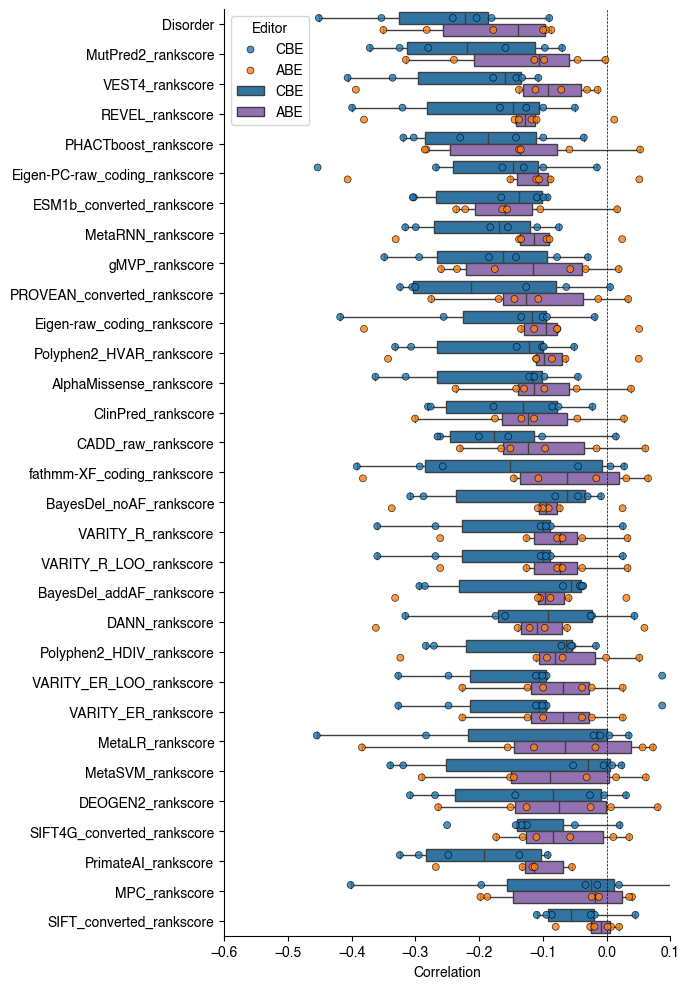

In [688]:
#aa = pd.concat(spear_holder).reset_index(drop=True)
#aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list() 
vep_order = [i for i in vep_order if i in veps + [' Disorder']]
vep_order = [i for i in vep_order if i not in no_full_stats]
# Step 2: Create the stripplotfig

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',}
              #'CDK2':'goldenrod',
              #'CDK4':'tab:red', 
              #'CDK6':'tab:orange',}


fig, ax = plt.subplots(figsize=(7,10))

palette = color_dict.values()
hue_order = color_dict.keys()

sns.stripplot(
    data=aa,
    y='VEP',
    x='Correlation',
    order=vep_order,          # descending order by median
    hue='Editor',               # or 'Editor'
    dodge=True,
    jitter=False,
    size=5,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    #hue_order = hue_order,
    #palette=palette
)

sns.boxplot(data=aa,y='VEP', x='Correlation',hue='Editor', order=vep_order, showfliers=False, palette=['tab:blue', 'tab:purple'])

#ax.set_yticklabels([i[:-10] for i in vep_order])
ax.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('')
ax.set_xlim(-.6, .1)
fig.tight_layout()

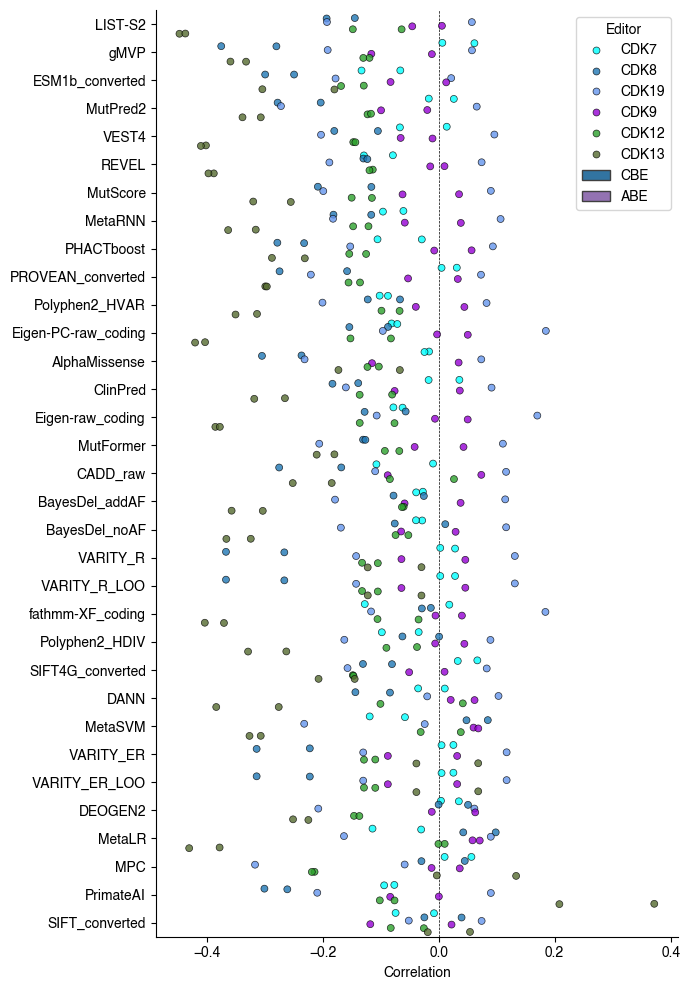

In [597]:
aa = pd.concat(pear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()
vep_order = [i for i in vep_order if i in veps]
# Step 2: Create the stripplotfig

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',}
              #'CDK2':'goldenrod',
              #'CDK4':'tab:red', 
              #'CDK6':'tab:orange',}


fig, ax = plt.subplots(figsize=(7,10))

palette = color_dict.values()
hue_order = color_dict.keys()

sns.stripplot(
    data=aa,
    y='VEP',
    x='Correlation',
    order=vep_order,          # descending order by median
    hue='Gene',               # or 'Editor'
    dodge=True,
    jitter=True,
    size=5,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    hue_order = hue_order,
    palette=palette
)

sns.boxplot(data=aa,y='VEP', x='Correlation',hue='Editor', order=vep_order, palette=['tab:blue', 'tab:purple'],
            meanline=True,
            meanprops={'color': 'k', 'ls': '-', 'lw': 2},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            showfliers=False,
            showbox=False,
            showcaps=False,ax=ax)

ax.set_yticklabels([i[:-10] for i in vep_order])
ax.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('')
fig.tight_layout()

<Axes: xlabel='Correlation', ylabel='VEP'>

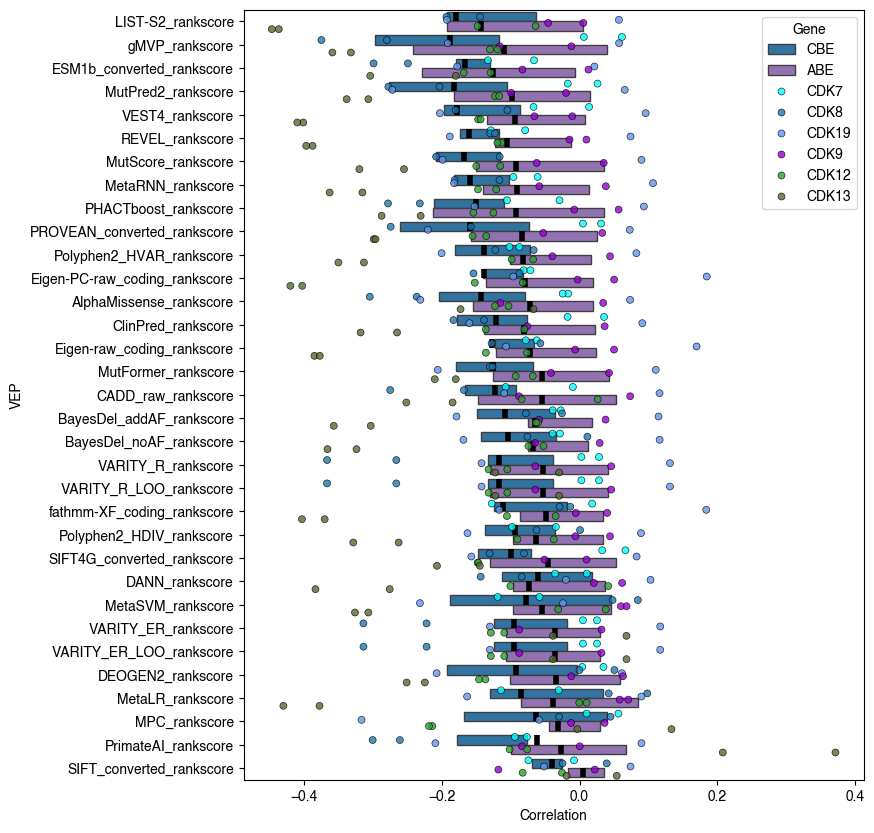

In [636]:
plt.figure(figsize=(8,10))
sns.boxplot(data=aa,y='VEP', x='Correlation',hue='Editor', order=vep_order, palette=['tab:blue', 'tab:purple'],
            meanline=True,
            showmeans=True,
            meanprops={'color': 'k', 'ls': '-', 'lw': 4},
            medianprops={'visible': False, 'lw':3},
            whiskerprops={'visible': False},
            showfliers=False,
            showbox=True,
            showcaps=False)

sns.stripplot(
    data=aa,
    y='VEP',
    x='Correlation',
    order=vep_order,          # descending order by median
    hue='Gene',               # or 'Editor'
    dodge=True,
    jitter=False,
    size=5,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    hue_order = hue_order,
    palette=palette
)

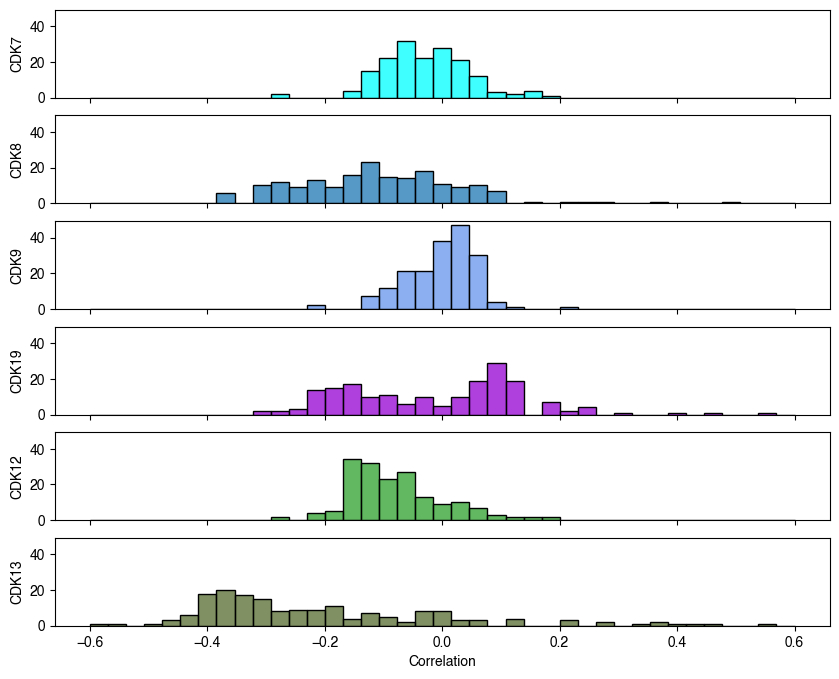

In [622]:
fig, ax = plt.subplots(len(genes),1,figsize=(10,8), sharex=True, sharey=True)
for i,gene in enumerate(genes):
    sns.histplot(data=aa[aa['Gene']==gene], ax=ax[i], x='Correlation', color=list(palette)[i], bins=np.linspace(-.6,.6,40))
    ax[i].set_ylabel(f'{gene}')

In [631]:
vep_order

['LIST-S2_rankscore',
 'gMVP_rankscore',
 'ESM1b_converted_rankscore',
 'MutPred2_rankscore',
 'VEST4_rankscore',
 'REVEL_rankscore',
 'MutScore_rankscore',
 'MetaRNN_rankscore',
 'PHACTboost_rankscore',
 'PROVEAN_converted_rankscore',
 'Polyphen2_HVAR_rankscore',
 'Eigen-PC-raw_coding_rankscore',
 'AlphaMissense_rankscore',
 'ClinPred_rankscore',
 'Eigen-raw_coding_rankscore',
 'MutFormer_rankscore',
 'CADD_raw_rankscore',
 'BayesDel_addAF_rankscore',
 'BayesDel_noAF_rankscore',
 'VARITY_R_rankscore',
 'VARITY_R_LOO_rankscore',
 'fathmm-XF_coding_rankscore',
 'Polyphen2_HDIV_rankscore',
 'SIFT4G_converted_rankscore',
 'DANN_rankscore',
 'MetaSVM_rankscore',
 'VARITY_ER_rankscore',
 'VARITY_ER_LOO_rankscore',
 'DEOGEN2_rankscore',
 'MetaLR_rankscore',
 'MPC_rankscore',
 'PrimateAI_rankscore',
 'SIFT_converted_rankscore']

In [ ]:
showmeans=True,
            meanline=True,
            meanprops={'color': 'k', 'ls': '-', 'lw': 2},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=10,
            x="method",
            y="distance",
            data=planets,
            showfliers=False,
            showbox=False,
            showcaps=False,

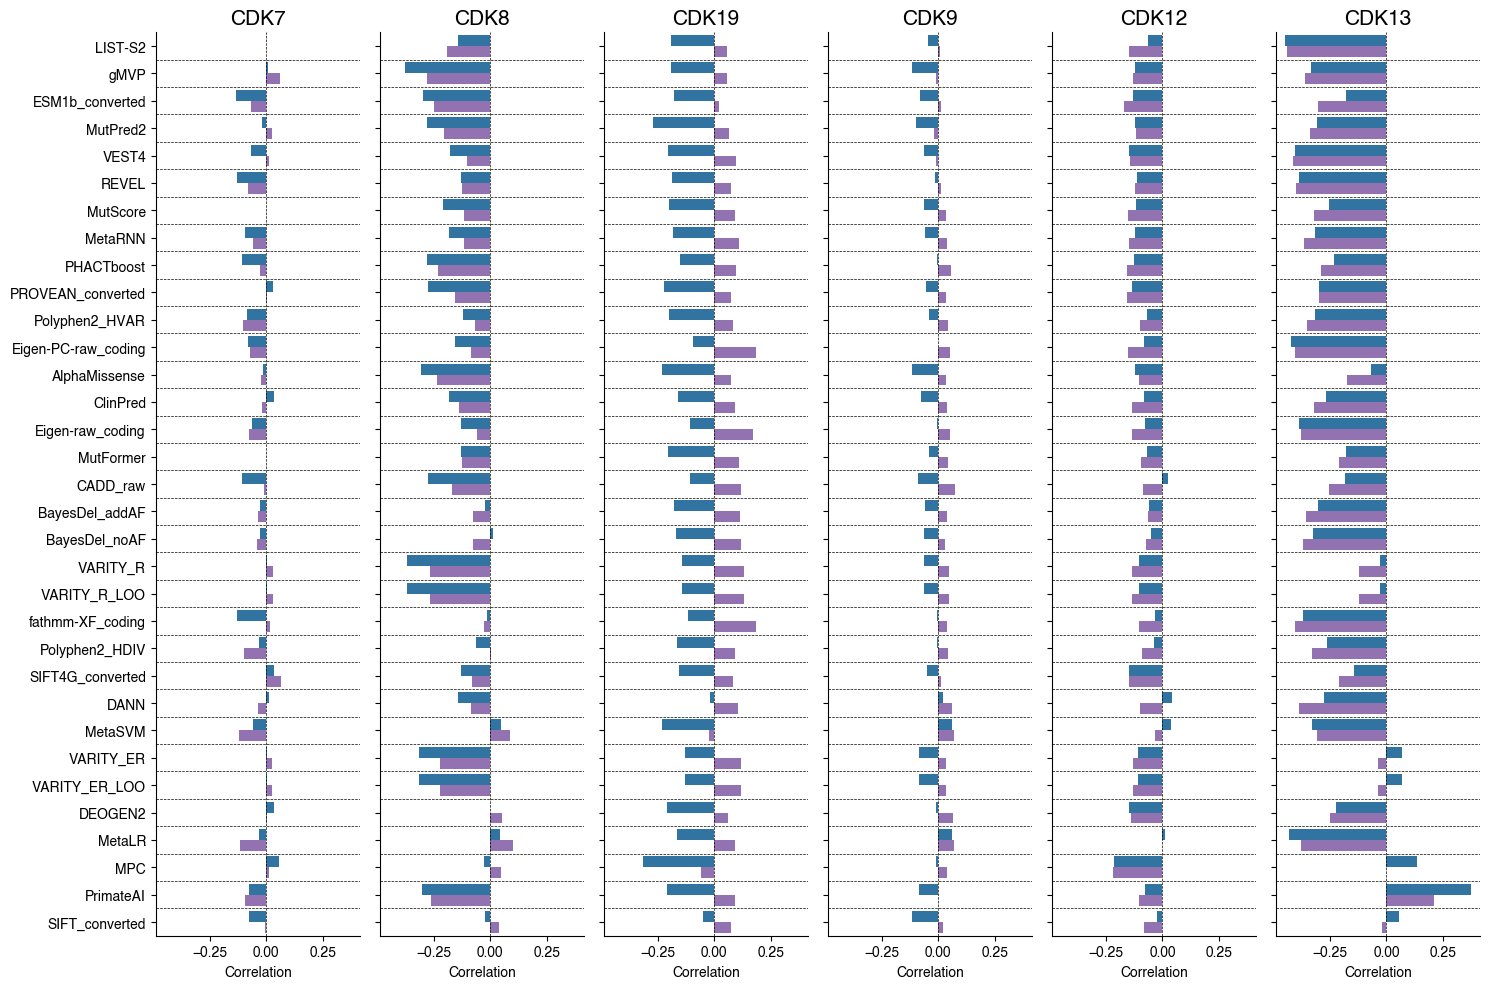

In [545]:
aa = pd.concat(pear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()
vep_order = [i for i in vep_order if i in veps]
# Step 2: Create the stripplotfig

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',}
              #'CDK2':'goldenrod',
              #'CDK4':'tab:red', 
              #'CDK6':'tab:orange',}


fig, ax = plt.subplots(1,6,figsize=(15,10), sharex=True, sharey=True)

palette = list(color_dict.values())
hue_order = list(color_dict.keys())

for i, gene in enumerate(hue_order):


    sns.barplot(data=aa[aa['Gene']==gene],y='VEP', x='Correlation', order=vep_order, ax=ax[i], hue='Editor', palette=['tab:blue', 'tab:purple'], legend=False)#,color=palette[i])

    ax[i].set_yticklabels([j[:-10] for j in vep_order])
    ax[i].axvline(0, linestyle='dashed', color='black', linewidth=0.5)

    for k in range(len(vep_order)):
        ax[i].axhline(k+0.5, linestyle='dashed', color='black', linewidth=0.5)

    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].set_ylabel('')
    ax[i].set_title(gene, fontsize=15)

fig.tight_layout()

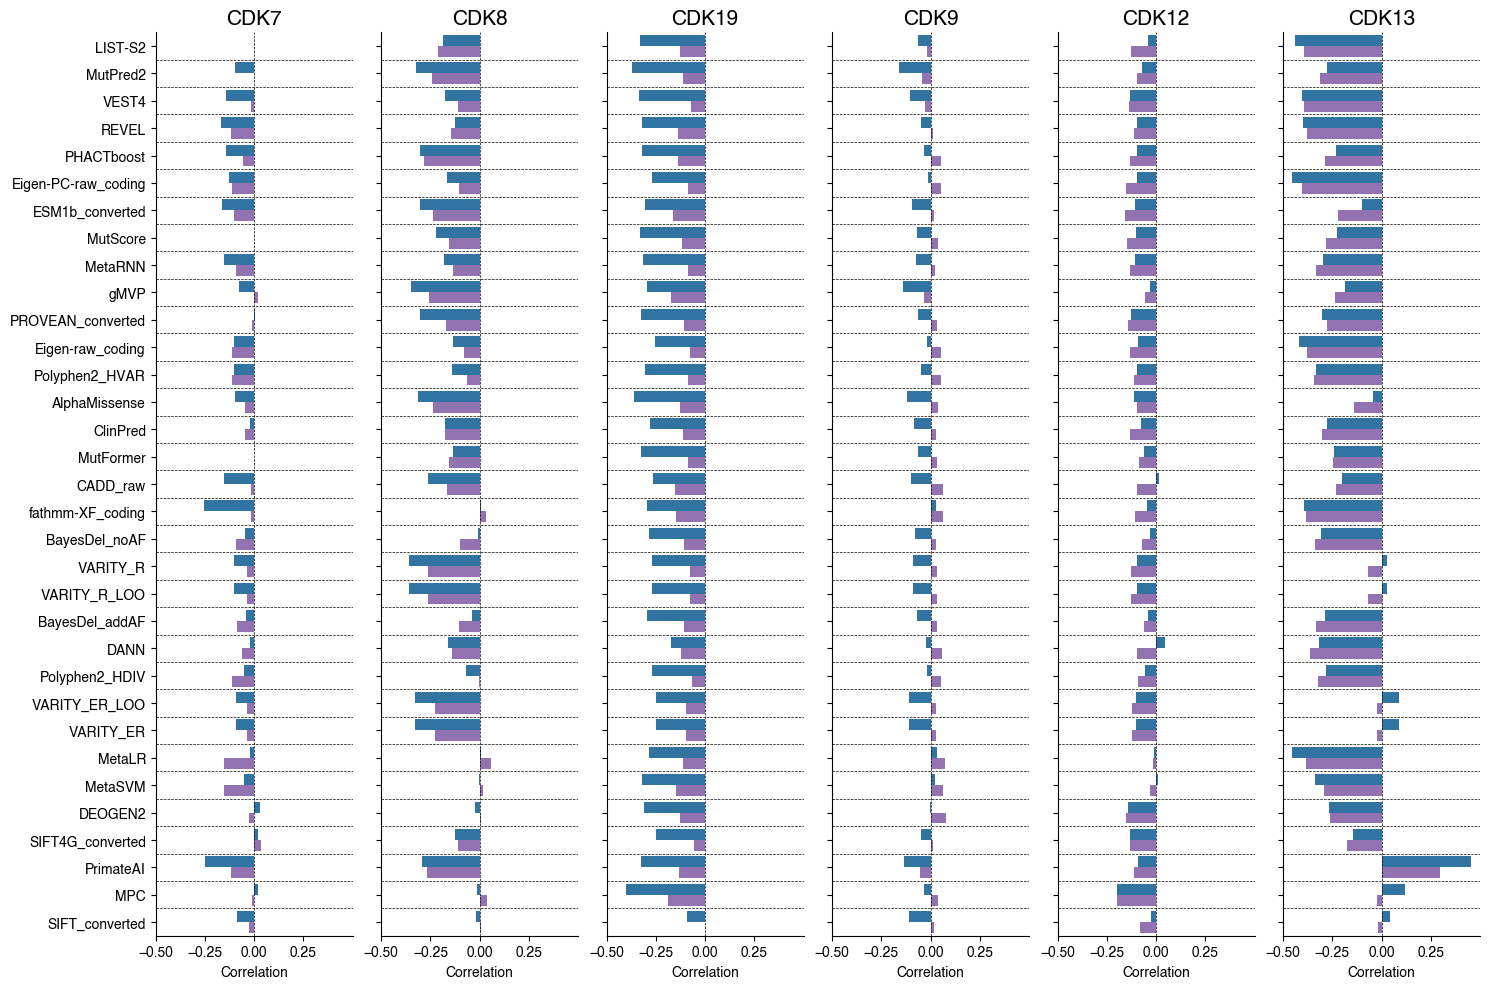

In [546]:
aa = pd.concat(spear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()
vep_order = [i for i in vep_order if i in veps]
# Step 2: Create the stripplotfig

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',}
              #'CDK2':'goldenrod',
              #'CDK4':'tab:red', 
              #'CDK6':'tab:orange',}


fig, ax = plt.subplots(1,6,figsize=(15,10), sharex=True, sharey=True)

palette = list(color_dict.values())
hue_order = list(color_dict.keys())

for i, gene in enumerate(hue_order):


    sns.barplot(data=aa[aa['Gene']==gene],y='VEP', x='Correlation', order=vep_order, ax=ax[i], hue='Editor', palette=['tab:blue', 'tab:purple'], legend=False)#,color=palette[i])

    ax[i].set_yticklabels([j[:-10] for j in vep_order])
    ax[i].axvline(0, linestyle='dashed', color='black', linewidth=0.5)

    for k in range(len(vep_order)):
        ax[i].axhline(k+0.5, linestyle='dashed', color='black', linewidth=0.5)

    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].set_ylabel('')
    ax[i].set_title(gene, fontsize=15)

fig.tight_layout()

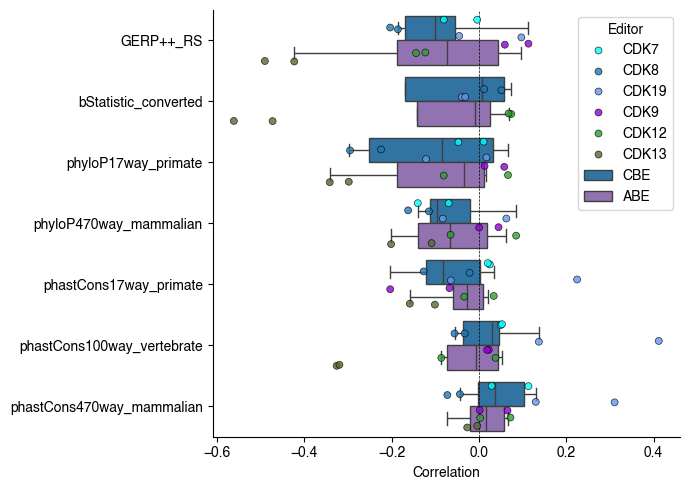

In [533]:
aa = pd.concat(pear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()
vep_order = [i for i in vep_order if i in cons]
# Step 2: Create the stripplotfig

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',}
              #'CDK2':'goldenrod',
              #'CDK4':'tab:red', 
              #'CDK6':'tab:orange',}


fig, ax = plt.subplots(figsize=(7,5))

palette = color_dict.values()
hue_order = color_dict.keys()

sns.stripplot(
    data=aa,
    y='VEP',
    x='Correlation',
    order=vep_order,          # descending order by median
    hue='Gene',               # or 'Editor'
    dodge=True,
    jitter=True,
    size=5,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    hue_order = hue_order,
    palette=palette
)

sns.boxplot(data=aa,y='VEP', x='Correlation',hue='Editor', order=vep_order, showfliers=False, palette=['tab:blue', 'tab:purple'])

ax.set_yticklabels([i[:-10] for i in vep_order])
ax.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('')
fig.tight_layout()

In [ ]:
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()

RS = [i for i in vep_order if ('_rankscore' or 'RS') in i]

len(RS)

cons = ['GERP++_RS_rankscore',
        'GERP++_NR'
        'phyloP100way_vertebrate_rankscore',
        'phyloP17way_primate_rankscore',
        'phyloP470way_mammalian_rankscore',
        'phastCons17way_primate_rankscore',
        'phastCons470way_mammalian_rankscore',
        'phastCons100way_vertebrate_rankscore',
        'bStatistic_converted_rankscore',
        ]

veps = ['LIST-S2_rankscore',
 'gMVP_rankscore',
 'ESM1b_converted_rankscore',
 'MutPred2_rankscore',
 'VEST4_rankscore',
 'REVEL_rankscore',
 'MutScore_rankscore',
 'MetaRNN_rankscore',
 'PHACTboost_rankscore',
 'PROVEAN_converted_rankscore',
 'Polyphen2_HVAR_rankscore',
 'Eigen-PC-raw_coding_rankscore',
 'AlphaMissense_rankscore',
 'ClinPred_rankscore',
 'Eigen-raw_coding_rankscore',
 'MutFormer_rankscore',
 'CADD_raw_rankscore',
 'BayesDel_addAF_rankscore',
 'BayesDel_noAF_rankscore',
 'VARITY_R_rankscore',
 'VARITY_R_LOO_rankscore',
 'fathmm-XF_coding_rankscore',
 'Polyphen2_HDIV_rankscore',
 'SIFT4G_converted_rankscore',
 'DANN_rankscore',
 'MetaSVM_rankscore',
 'VARITY_ER_rankscore',
 'VARITY_ER_LOO_rankscore',
 'DEOGEN2_rankscore',
 'MetaLR_rankscore',
 'MPC_rankscore',
 'PrimateAI_rankscore',
 'MVP_rankscore',
 'SIFT_converted_rankscore',
 'M-CAP_rankscore',
 'MutationAssessor_rankscore',
 ]




36

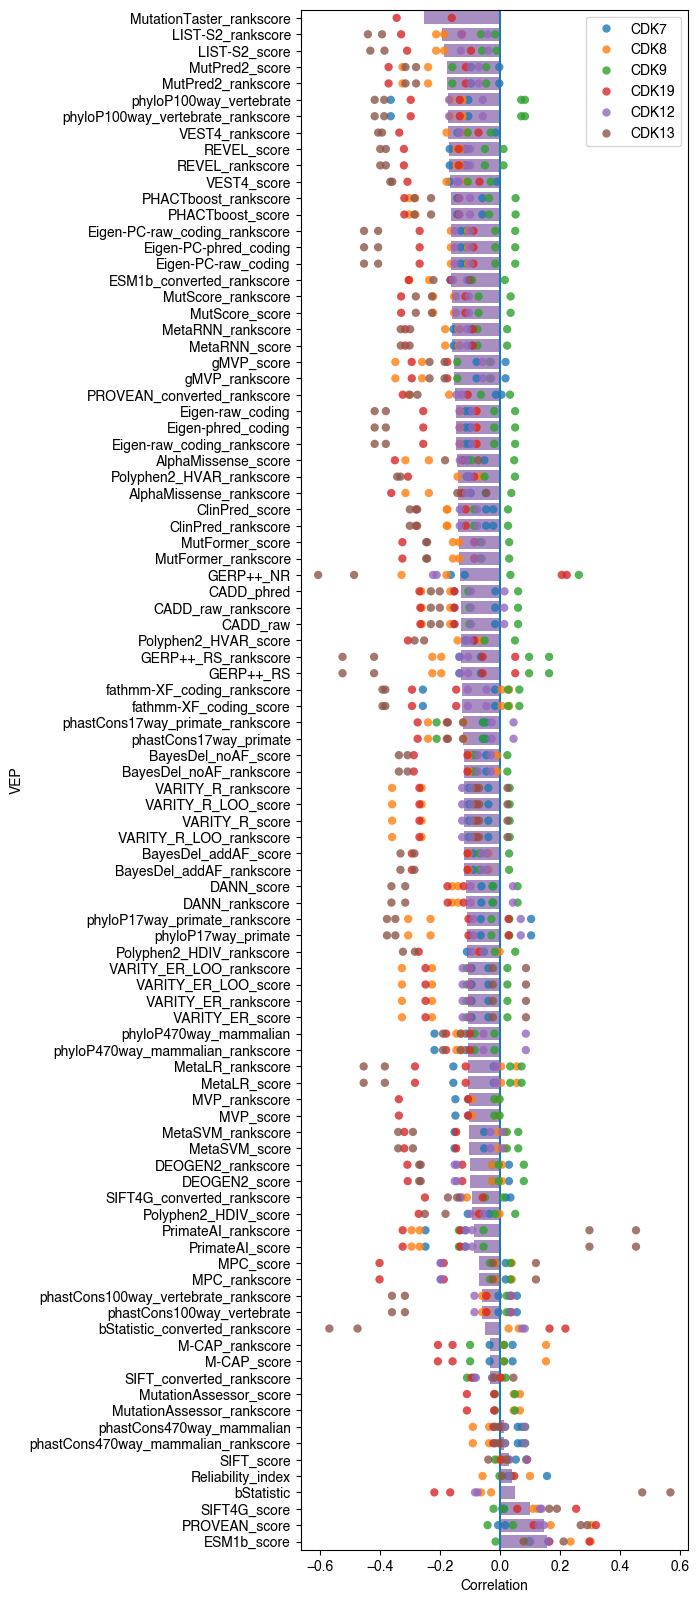

In [425]:
aa = pd.concat(spear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()

# Step 2: Create the stripplotfig

fig, ax = plt.subplots(figsize=(5,20))

sns.stripplot(
    data=aa,
    y='VEP',
    x='Correlation',
    order=vep_order,          # descending order by median
    hue='Gene',               # or 'Editor'
    dodge=False,
    jitter=False,
    size=6,
    alpha=0.8
)

sns.barplot(
    data=aa,
    y='VEP',
    x='Correlation',
    order=vep_order,          # descending order by median             # or 'Editor'
    alpha=0.8,
    errorbar=None
)
ax.axvline(0)

<Axes: xlabel='Gene', ylabel='Correlation'>

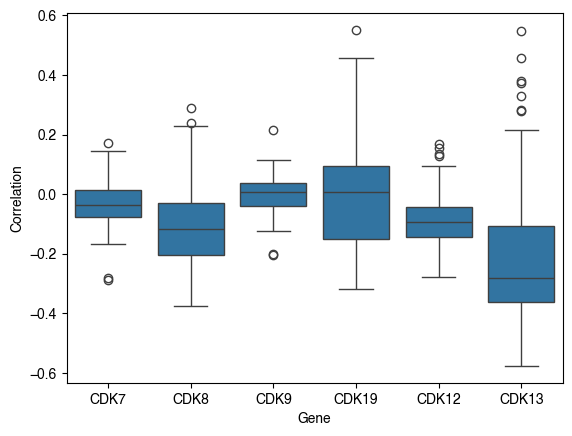

In [417]:
sns.boxplot(data=aa, x='Gene', y='Correlation')

<Axes: xlabel='value', ylabel='VEP'>

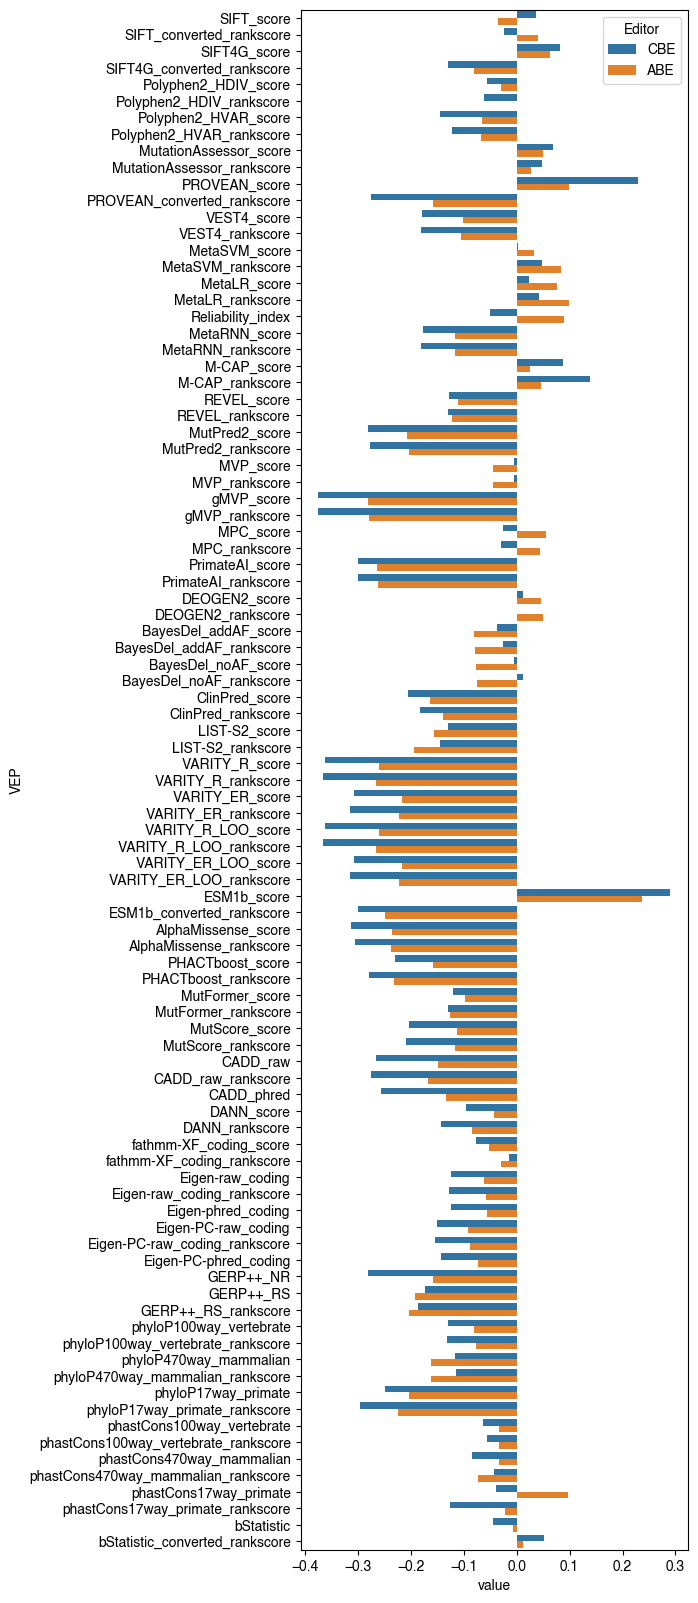

In [365]:
fig, ax = plt.subplots(figsize=(5,20))
sns.barplot(data=pear.melt(id_vars = ('VEP','Gene', 'Editor')).reset_index(), y='VEP', x='value', hue='Editor')

In [333]:

abe_pear_list = []
abe_spear_list = []
cbe_pear_list = []
cbe_spear_list = []
vep_name = []

for i in comb_VEP_cons:
    
    try:
        cbe_spear = scipy.stats.spearmanr([float(i) for i in merge_cbe[i]], merge_cbe['LFC_median_T0']).statistic
        cbe_pear = scipy.stats.pearsonr([float(i) for i in merge_cbe[i]], merge_cbe['LFC_median_T0']).statistic

        abe_spear = scipy.stats.spearmanr([float(i) for i in merge_abe[i]], merge_abe['LFC_median_T0']).statistic
        abe_pear = scipy.stats.pearsonr([float(i) for i in merge_abe[i]], merge_abe['LFC_median_T0']).statistic

        vep_name.append(i)
        abe_pear_list.append(abe_pear)
        abe_spear_list.append(abe_spear)
        cbe_pear_list.append(cbe_pear)
        cbe_spear_list.append(cbe_spear)
        
    except:
        continue

In [334]:
CBE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_pear_list,vep_name])))
ABE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_pear_list,vep_name])))
CBE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_spear_list,vep_name])))
ABE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_spear_list,vep_name])))

CBE_pear_df['Editor']='CBE'
ABE_pear_df['Editor']='ABE'
CBE_spear_df['Editor']='CBE'
ABE_spear_df['Editor']='ABE'

spearman_df = pd.concat((CBE_spear_df, ABE_spear_df))
pearson_df = pd.concat((CBE_pear_df, ABE_pear_df))

In [335]:
spearman_df.sort_values(by='Correlation')[:20]

,Gene,Correlation,VEP,Editor
70,CDK12,-0.223117,GERP++_NR,CBE
70,CDK12,-0.211102,GERP++_NR,ABE
26,CDK12,-0.197999,MPC_rankscore,ABE
25,CDK12,-0.197994,MPC_score,ABE
25,CDK12,-0.196669,MPC_score,CBE
26,CDK12,-0.196652,MPC_rankscore,CBE
73,CDK12,-0.169242,phyloP100way_vertebrate,ABE
74,CDK12,-0.169242,phyloP100way_vertebrate_rankscore,ABE
48,CDK12,-0.156160,ESM1b_converted_rankscore,ABE
68,CDK12,-0.151024,Eigen-PC-raw_coding_rankscore,ABE


# Correlation among predictors

In [593]:
g = 'CDK9'
a1 = db_dict[g]

a1 = a1[a1['LIST-S2_rankscore']!='.']


v2 = ['LIST-S2_rankscore',
 'MutPred2_rankscore',
 'VEST4_rankscore',
 'REVEL_rankscore',
 'PHACTboost_rankscore',
 'Eigen-PC-raw_coding_rankscore',
 'ESM1b_converted_rankscore',
 'MetaRNN_rankscore',
 'gMVP_rankscore',
 'PROVEAN_converted_rankscore',
 'Eigen-raw_coding_rankscore',
 'Polyphen2_HVAR_rankscore',
 'AlphaMissense_rankscore',
 'ClinPred_rankscore',
 'CADD_raw_rankscore',
 'fathmm-XF_coding_rankscore',
 'BayesDel_noAF_rankscore',
 'VARITY_R_rankscore',
 'VARITY_R_LOO_rankscore',
 'BayesDel_addAF_rankscore',
 'DANN_rankscore',
 'Polyphen2_HDIV_rankscore',
 'VARITY_ER_LOO_rankscore',
 'VARITY_ER_rankscore',
 'MetaLR_rankscore',
 'MetaSVM_rankscore',
 'DEOGEN2_rankscore',
 'SIFT4G_converted_rankscore',
 'PrimateAI_rankscore',
 'MPC_rankscore',
 'SIFT_converted_rankscore']

a1 = a1[v2]

for col in a1.columns:
    a1[col] = pd.to_numeric(a1[col])


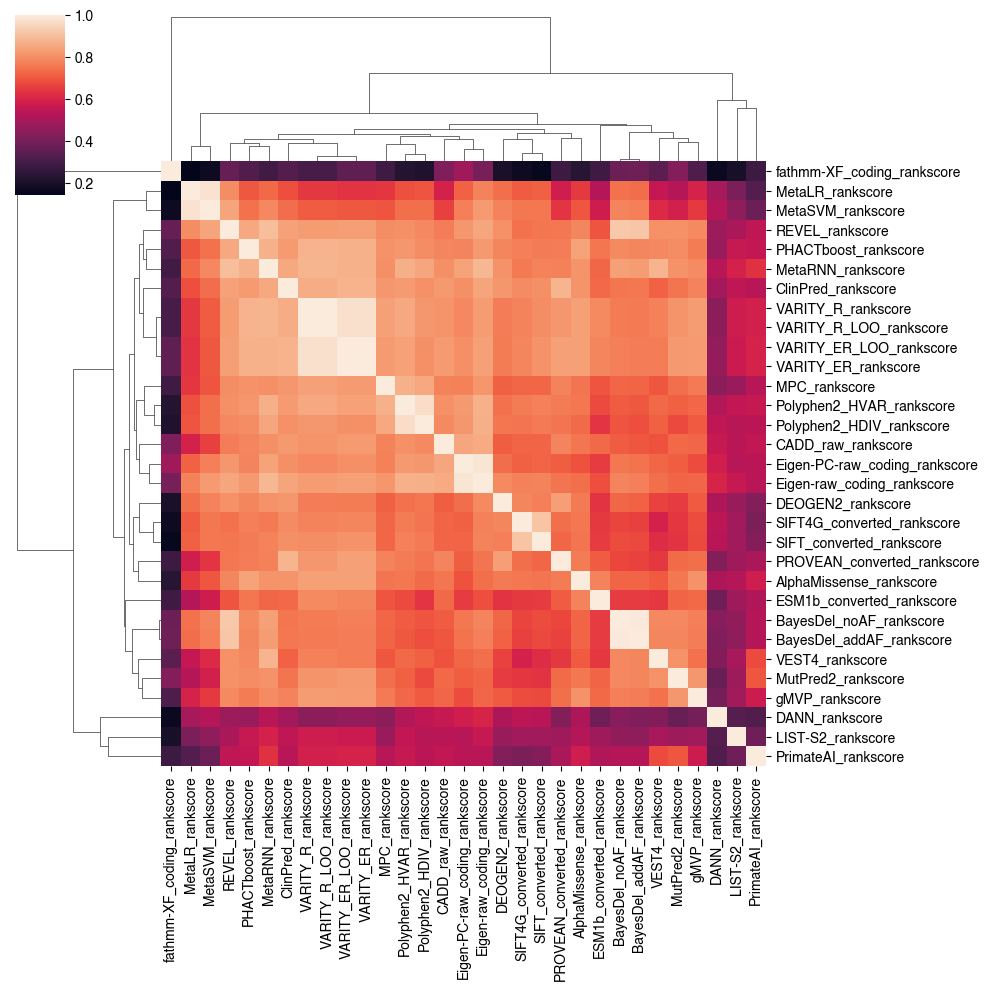

In [594]:
sns.clustermap(a1.corr(method='spearman'))

In [586]:
for i in vep_order:
    if '.' in list(a1[i]):
        print(i)

MutScore_rankscore
MutFormer_rankscore


# Disorder analysis

In [457]:
d = '../../source_data/20_metapredict_disorder'

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

d_list = []
for gene in genes:
    disorder = pd.read_csv(f'{d}/{gene}_disorder_scores.csv').rename(columns = {' Index':'Codon'})
    disorder['Codon'] = [str(i) for i in disorder['Codon']]
    d_list.append(disorder)
disorder_dict = dict(zip(genes, d_list))

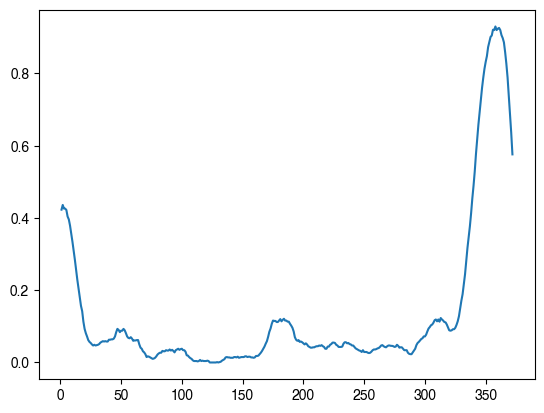

In [480]:
d = disorder_dict['CDK9']
plt.plot([int(i) for i in d['Codon']], d[' Disorder'])

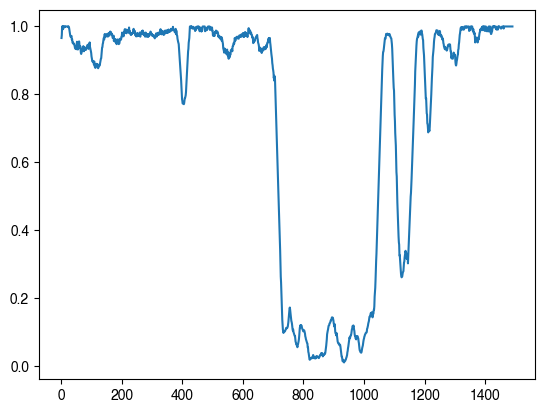

In [572]:
d = disorder_dict['CDK12']
plt.plot([int(i) for i in d['Codon']], d[' Disorder'])

In [ ]:
def corr_disorder(gene, min_edit, min_base_counts):
    edits = sav_dict[gene].rename(columns = {'HGVSp_new':'HGVSp_VEP'})

    #can limit it to only SNPs for direct comparison; essentially the same result
    #inc_edits = list(db_dict[gene]['HGVSp_VEP'])

    mis = edits[edits['Var_Type']=='Missense']

   #mis_abe = mis[(mis['Editor']=='ABE') & (mis['HGVSp_VEP'].isin(inc_edits))].reset_index(drop=True)
    #mis_cbe = mis[(mis['Editor']=='CBE') & (mis['HGVSp_VEP'].isin(inc_edits))].reset_index(drop=True)
    mis_abe = mis[(mis['Editor']=='ABE')].reset_index(drop=True)
    mis_cbe = mis[(mis['Editor']=='CBE')].reset_index(drop=True)

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
        lfc_info_abe = ABE1[ABE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_T0']]
        lfc_info_cbe = CBE1[CBE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_T0']]
    elif gene in ['CDK12', 'CDK13']:
        lfc_info_abe = ABE2[ABE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_ABE_T0']].rename(columns = {'LFC_median_ABE_T0':'LFC_median_T0'})
        lfc_info_cbe = CBE2[CBE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_CBE_T0']].rename(columns = {'LFC_median_CBE_T0':'LFC_median_T0'})

    merge_cbe = pd.merge(mis_cbe, lfc_info_cbe, on='gRNA_id')
    merge_abe = pd.merge(mis_abe, lfc_info_abe, on='gRNA_id')


    merge_cbe = merge_cbe[merge_cbe['%Reads']>=min_edit]
    merge_abe = merge_abe[merge_abe['%Reads']>=min_edit]

    dis1 = disorder_dict[gene]

    merge_cbe2 = pd.merge(merge_cbe, dis1, on='Codon')
    merge_abe2 = pd.merge(merge_abe, dis1, on='Codon')


    abe_pear_list = []
    abe_spear_list = []
    cbe_pear_list = []
    cbe_spear_list = []
    vep_name = []


    i = ' Disorder'
    cbe_spear = scipy.stats.spearmanr([float(i) for i in merge_cbe2[i]], merge_cbe2['LFC_median_T0']).statistic
    cbe_pear = scipy.stats.pearsonr([float(i) for i in merge_cbe2[i]], merge_cbe2['LFC_median_T0']).statistic

    abe_spear = scipy.stats.spearmanr([float(i) for i in merge_abe2[i]], merge_abe2['LFC_median_T0']).statistic
    abe_pear = scipy.stats.pearsonr([float(i) for i in merge_abe2[i]], merge_abe2['LFC_median_T0']).statistic

    vep_name.append(i)
    abe_pear_list.append(abe_pear)
    abe_spear_list.append(abe_spear)
    cbe_pear_list.append(cbe_pear)
    cbe_spear_list.append(cbe_spear)
            

    CBE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_pear_list,vep_name])))
    ABE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_pear_list,vep_name])))
    CBE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_spear_list,vep_name])))
    ABE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_spear_list,vep_name])))

    CBE_pear_df['Editor']='CBE'
    ABE_pear_df['Editor']='ABE'
    CBE_spear_df['Editor']='CBE'
    ABE_spear_df['Editor']='ABE'

    spearman_df = pd.concat((CBE_spear_df, ABE_spear_df))
    pearson_df = pd.concat((CBE_pear_df, ABE_pear_df))

    return spearman_df, pearson_df



In [869]:
ABE1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/ABE_subpool1_barcode_Plasmid_base.csv')
CBE1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CBE_subpool1_barcode_Plasmid_base.csv')

ABE2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_ABE_barcode_Plasmid_base.csv')
CBE2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_CBE_barcode_Plasmid_base.csv')

In [878]:

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']
min_edit = 20
min_base_counts = 100

pear_holder2 = []
spear_holder2 = []
for gene in genes:
    spearman_df, pearson_df = corr_disorder(gene, min_edit, min_base_counts)
    pear_holder2.append(pearson_df)
    spear_holder2.append(spearman_df)



In [871]:
genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

pear_holder = []
spear_holder = []
for gene in genes:

    pear, spear = corr_maker(gene, min_edit, min_base_counts)
    pear_holder.append(pear)
    spear_holder.append(spear)

In [872]:
vep_categories = {
"Meta": ['VARITY_R_rankscore','DEOGEN2_rankscore', 'MetaSVM_rankscore','MetaLR_rankscore',
         'REVEL_rankscore','MutScore_rankscore','BayesDel_addAF_rankscore', 'ClinPred_rankscore',  ],

"ML": ['VEST4_rankscore', 'CADD_raw_rankscore','fathmm-XF_coding_rankscore','gMVP_rankscore',
         'AlphaMissense_rankscore','ESM1b_converted_rankscore','PrimateAI_rankscore','Polyphen2_HVAR_rankscore',
         'DANN_rankscore','PHACTboost_rankscore', 'MutFormer_rankscore', 'LIST-S2_rankscore', 'MetaRNN_rankscore',
          'MutPred2_rankscore','Eigen-PC-raw_coding_rankscore'],

"Conservation": ['SIFT4G_converted_rankscore','PROVEAN_converted_rankscore', 'GERP++_RS_rankscore',
        'GERP++_NR',
        'phyloP100way_vertebrate_rankscore',
        'phyloP17way_primate_rankscore',
        'phyloP470way_mammalian_rankscore',
        'phastCons17way_primate_rankscore',
        'phastCons470way_mammalian_rankscore',
        'phastCons100way_vertebrate_rankscore',
        'bStatistic_converted_rankscore'],

"Biophysical": [" Disorder"]
}

flat_veps = flat = [item for sublist in list(vep_categories.values()) for item in sublist]
flat_veps

['VARITY_R_rankscore',
 'DEOGEN2_rankscore',
 'MetaSVM_rankscore',
 'MetaLR_rankscore',
 'REVEL_rankscore',
 'MutScore_rankscore',
 'BayesDel_addAF_rankscore',
 'ClinPred_rankscore',
 'VEST4_rankscore',
 'CADD_raw_rankscore',
 'fathmm-XF_coding_rankscore',
 'gMVP_rankscore',
 'AlphaMissense_rankscore',
 'ESM1b_converted_rankscore',
 'PrimateAI_rankscore',
 'Polyphen2_HVAR_rankscore',
 'DANN_rankscore',
 'PHACTboost_rankscore',
 'MutFormer_rankscore',
 'LIST-S2_rankscore',
 'MetaRNN_rankscore',
 'MutPred2_rankscore',
 'Eigen-PC-raw_coding_rankscore',
 'SIFT4G_converted_rankscore',
 'PROVEAN_converted_rankscore',
 'GERP++_RS_rankscore',
 'GERP++_NR',
 'phyloP100way_vertebrate_rankscore',
 'phyloP17way_primate_rankscore',
 'phyloP470way_mammalian_rankscore',
 'phastCons17way_primate_rankscore',
 'phastCons470way_mammalian_rankscore',
 'phastCons100way_vertebrate_rankscore',
 'bStatistic_converted_rankscore',
 ' Disorder']

In [873]:
vep_names = {'VARITY_R_rankscore': 'VARITY_R',
 'DEOGEN2_rankscore': 'DEOGEN2',
 'MetaSVM_rankscore':'MetaSVM',
 'MetaLR_rankscore':'MetaLR',
 'REVEL_rankscore':'REVEL',
 'MutScore_rankscore':'MutScore',
 'BayesDel_addAF_rankscore':'BayesDel (addAF)',
 'ClinPred_rankscore':'ClinPred',
 'VEST4_rankscore':'VEST4',
 'CADD_raw_rankscore':'CADD',
 'fathmm-XF_coding_rankscore':'fathmm-XF',
 'gMVP_rankscore':'gMVP',
 'AlphaMissense_rankscore':'AlphaMissense',
 'ESM1b_converted_rankscore':'ESM1b',
 'PrimateAI_rankscore':'PrimateAI',
 'Polyphen2_HVAR_rankscore':'Polyphen2_HVAR',
 'DANN_rankscore':'DANN',
 'PHACTboost_rankscore':'PHACTboost',
 'MutFormer_rankscore':'MutFormer',
 'LIST-S2_rankscore':'LIST-S2',
 'MetaRNN_rankscore':'MetaRNN',
 'MutPred2_rankscore':'MutPred2',
 'Eigen-PC-raw_coding_rankscore':'Eigen-PC',
 'SIFT4G_converted_rankscore':'SIFT4G',
 'PROVEAN_converted_rankscore':'PROVEAN',
 'GERP++_RS_rankscore':'GERP++_RS',
 'GERP++_NR':'GERP++_NR',
 'phyloP100way_vertebrate_rankscore':'phyloP100way (vertebrate)',
 'phyloP17way_primate_rankscore':'phyloP17way (primate)',
 'phyloP470way_mammalian_rankscore':'phyloP470way (mammalian)',
 'phastCons17way_primate_rankscore':'phastCons17way (primate)',
 'phastCons470way_mammalian_rankscore':'phastCons470way (mammalian)',
 'phastCons100way_vertebrate_rankscore':'phastCons100way (vertebrate)',
 'bStatistic_converted_rankscore':'bStatistic',
 ' Disorder':'Disorder (Metapredict)*'}

In [874]:
a = pd.concat(spear_holder).reset_index(drop=True)
bb = pd.concat(spear_holder2).reset_index(drop=True)

aa = pd.concat((a, bb))
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)


aa.loc[aa['VEP']==' Disorder', 'Correlation'] = -np.asarray(aa.loc[aa['VEP']==' Disorder', 'Correlation'])
aa.loc[aa['VEP']==' Disorder']


u, c = np.unique(aa['VEP'], return_counts=True)
d1 = pd.DataFrame(dict(zip(['u','c'], [u,c])))
no_full_stats = list(d1[d1['c']!=12]['u'])

aa = aa[~aa['VEP'].isin(no_full_stats)].reset_index(drop=True)
aa = aa[aa['VEP'].isin(flat_veps)].reset_index(drop=True)
#aa['Name'] = 


def categorize_vep(vep):
    for category, veps in vep_categories.items():
        if vep in veps:
            return category
    return 'other'

aa['VEP_category'] = aa['VEP'].apply(categorize_vep)
aa['Name'] = [vep_names[i] for i in aa['VEP']]


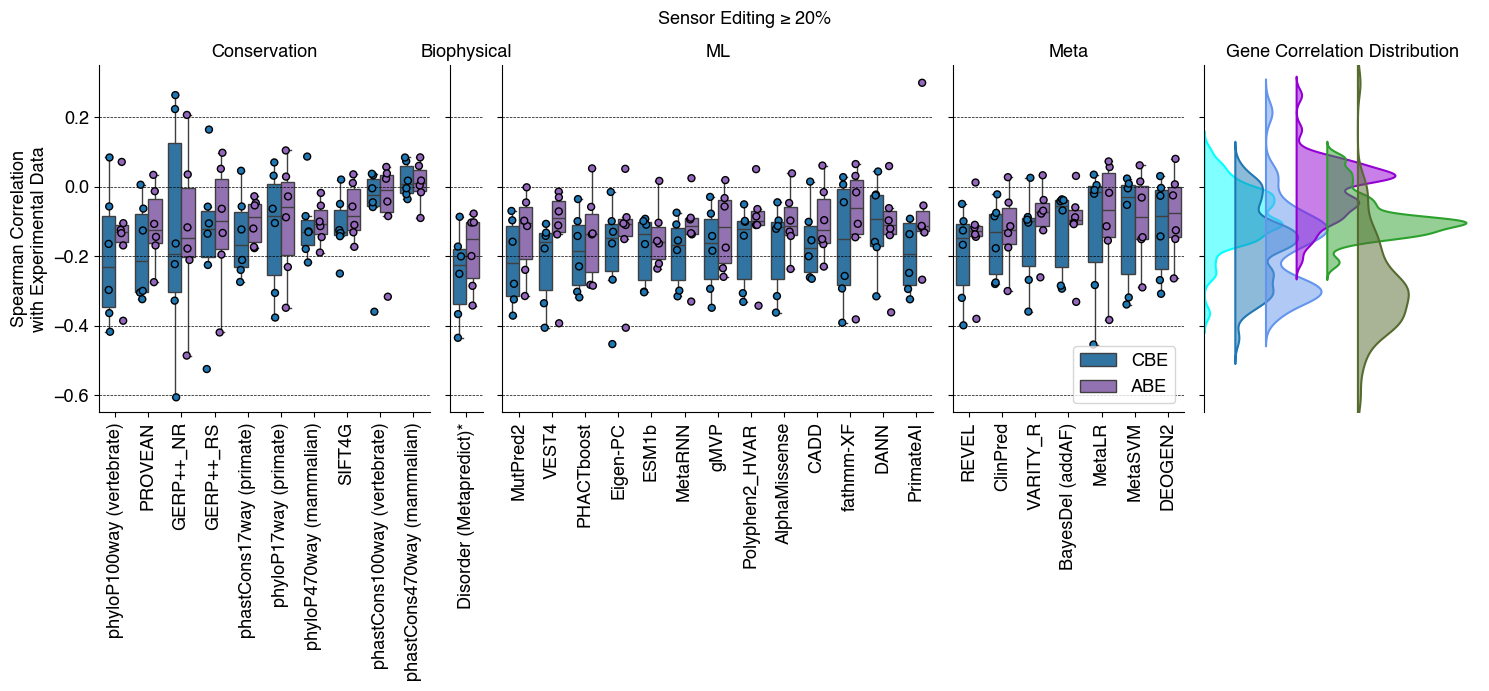

In [875]:
list(vep_categories.keys())

o = ['Conservation', 'Biophysical', 'ML', 'Meta']

fig, ax = plt.subplots(1,5,figsize=(15,7), width_ratios=[120, 12, 156, 84,100], sharey=True)

for i, val in enumerate(o):
    g = aa[aa['VEP_category']==val].reset_index()
    vep_order = g.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list() 

    sns.stripplot(data=g,x='VEP', y='Correlation',hue='Editor', order=vep_order, ax=ax[i], palette=['tab:blue', 'tab:purple'], edgecolor='black', linewidth=1, dodge=True, legend=False)

    if i==3:
        sns.boxplot(data=g,x='VEP', y='Correlation',hue='Editor', showfliers=False, order=vep_order, ax=ax[i], palette=['tab:blue', 'tab:purple'], legend=True)
        ax[i].legend(loc='lower right', fontsize=13)
    else:
        sns.boxplot(data=g,x='VEP', y='Correlation',hue='Editor', showfliers=False, order=vep_order, ax=ax[i], palette=['tab:blue', 'tab:purple'], legend=False)


    ax[i].set_xticklabels([vep_names[i] for i in vep_order], rotation=90)
    ax[i].set_xlabel('')

    ls = [0.2,  0,  -.2,  -.4, -.6]
    for j in ls:
        ax[i].axhline(j, linewidth=0.5, linestyle='dashed', color='black')
    
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].tick_params(axis='both', which='major', labelsize=13)
    ax[i].set_title(val, fontsize=13)
    


color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',}

palette = list(color_dict.values())
genes = list(color_dict.keys())

#for i,gene in enumerate(genes):
    #sns.histplot(data=aa[aa['Gene']==gene], ax=ax[4], y='Correlation', color=palette[i], bins=np.linspace(-.6,.6,40))
    #ax[i].set_ylabel(f'{gene}')

offset = 2  # vertical offset between curves

for i, gene in enumerate(genes):
    data = aa[aa['Gene'] == gene]['Correlation']
    kde = sns.kdeplot(y=data, ax=ax[4], 
                bw_adjust=0.5,  # smoothness of KDE
                fill=True,
                color=palette[i],
                alpha=0.5,
                linewidth=1.5)

    # Manually shift the KDE vertically
    #ax[4].collections[-1].set_offsets(np.c_[ax[4].collections[-1].get_offsets()[:, 0],
    #                                     ax[4].collections[-1].get_offsets()[:, 1] + i * offset])
    # Add gene label
    #ax[4].text(-0.65, i * offset, gene, va='center', ha='right')

    path = kde.collections[-1].get_paths()[0]
    vertices = path.vertices
    vertices[:, 0] += i * offset  # shift x-coordinates
    #ax[4].text(i * offset, -0.65, gene, ha='center', va='top', fontsize=10)
    ax[4].set_xlim(0,18)
    ax[4].set_title('Gene Correlation Distribution', fontsize=13)
    ax[4].spines[['right', 'top','bottom']].set_visible(False)
    ax[4].set_xticks([])
    ax[4].set_xlabel('')
    ax[4].set_ylim(-.65,.35)


ax[0].set_ylabel('Spearman Correlation\nwith Experimental Data', fontsize=13)
fig.suptitle(f'Sensor Editing ≥ {min_edit}%', fontsize=13)
fig.tight_layout()

#fig.savefig('../../figures/VEP_plots.pdf', transparent=True)

In [899]:
sel = 'cdk9_catalytic'
sel.split('_')[0].upper()

'CDK9'

In [898]:
from matplotlib import colors
for i in color_dict.keys():

    hex = colors.to_hex(color_dict[i], keep_alpha=False)
    print(f'{i} {hex}')

CDK7 #00ffff
CDK8 #1f77b4
CDK19 #6495ed
CDK9 #9400d3
CDK12 #2ca02c
CDK13 #556b2f


# More Disorder Analysis

In [857]:
def control_maker(targ_ABE, targ_CBE, name_CBE, name_ABE, WT_cutoff, plot_ABE, plot_CBE):

    if plot_ABE==True:

        non_edited_ABE = targ_ABE[targ_ABE['WT_perc']>=WT_cutoff]
        non_edited_ABE['Guide Class'] = f'WT≥\n{WT_cutoff}%'

        intron_df_ABE = targ_ABE[targ_ABE['classification']=='intron']
        intron_df_ABE['Guide Class'] = 'Intron'
        nt_df_ABE = targ_ABE[targ_ABE['Gene']=='NT']
        nt_df_ABE['Guide Class'] = 'NT'

        controls_ABE = pd.concat((intron_df_ABE, nt_df_ABE, non_edited_ABE))

        controls_ABE['Editor']='ABE'
    #and CBE
    if plot_CBE==True:
        non_edited_CBE = targ_CBE[targ_CBE['WT_perc']>=WT_cutoff]
        non_edited_CBE['Guide Class'] = f'WT≥\n{WT_cutoff}%'

        intron_df_CBE = targ_CBE[targ_CBE['classification']=='intron']
        intron_df_CBE['Guide Class'] = 'Intron'
        nt_df_CBE = targ_CBE[targ_CBE['Gene']=='NT']
        nt_df_CBE['Guide Class'] = 'NT'
        controls_CBE = pd.concat((intron_df_CBE, nt_df_CBE, non_edited_CBE))

        controls_CBE['Editor']='CBE'
    #-----merging the control dfs for simplicity of plotting-------
    if plot_CBE==plot_ABE: 
        #make names match up
        controls_ABE = controls_ABE.rename(columns = {name_ABE:name_CBE})
        controls_combined = pd.concat((controls_CBE, controls_ABE))

    else:
        if plot_CBE==True:
            controls_combined = controls_CBE
        if plot_ABE==True:
            controls_combined = controls_ABE

    return controls_combined

def find_ranges(numbers):
    if not numbers:
        return []

    # Sort the list to ensure consecutive numbers are adjacent
    sorted_numbers = sorted(list(set(numbers)))  # Use set to handle duplicates

    ranges = []
    if not sorted_numbers:
        return ranges

    start_of_range = sorted_numbers[0]
    
    for i in range(1, len(sorted_numbers)):
        if sorted_numbers[i] != sorted_numbers[i-1] + 1:
            # End of current range, add it to the list
            ranges.append((start_of_range, sorted_numbers[i-1]))
            start_of_range = sorted_numbers[i] # Start a new range
    
    # Add the last range
    ranges.append((start_of_range, sorted_numbers[-1]))
    
    return ranges

In [865]:
def subpool2_plotter(m_CBE, m_ABE, targ_CBE, targ_ABE, condition_of_interest_CBE, condition_of_interest_ABE, true_name, min_base_counts, WT_cutoff_main, WT_cutoff_ctrl, FDR_cutoff, LFC_cutoff, plot_ABE=True, plot_CBE=True):


    genes = ['CDK12', 'CDK13']

    #targ_CBE2 = targ_CBE_SY[(targ_CBE_SY['DMSO_median_CBE']>=min_DMSO_counts) & (targ_CBE_SY['Gene'].isin(genes)) & (targ_CBE_SY['WT_perc']<WT_cutoff)]
    targ_CBE2 = targ_CBE[(targ_CBE['base_RAW']>=min_base_counts) & (targ_CBE['Gene'].isin(genes))& (targ_CBE['WT_perc']<WT_cutoff_main)]
    targ_ABE2 = targ_ABE[(targ_ABE['base_RAW']>=min_base_counts) & (targ_ABE['Gene'].isin(genes))& (targ_ABE['WT_perc']<WT_cutoff_main)]


    name_CBE = f'LFC_median_{condition_of_interest_CBE}'
    FDR_CBE = f'FDR_{condition_of_interest_CBE}'
    name_ABE = f'LFC_median_{condition_of_interest_ABE}'
    FDR_ABE = f'FDR_{condition_of_interest_ABE}'


    genes = ['CDK12', 'CDK13']
    ax_dict = {'CDK12':0, 'CDK13':1,}

    fig, ax = plt.subplots(1,3, figsize=(15,6), sharey=True, width_ratios=[1490, 1512, 500])

    xticks = [[0,250,500,750,1000,1250,1490],
            [0,250,500,750,1000,1250,1512],]

    #-------plot CBE--------
    if plot_CBE == True:
        for i, gene in enumerate(genes):
            s = targ_CBE2[targ_CBE2['Gene']==gene]
            
            x = ax_dict[gene]

            #bb1 = s[(s[name_CBE]<cutoff) | (s[name_CBE]>cutoff_low)]
            #bb2 = s[(s[name_CBE]>=cutoff) | (s[name_CBE]<=cutoff_low)]

            bb1 = s[(s[FDR_CBE]>FDR_cutoff) | ((s[name_CBE]<LFC_cutoff))]
            bb2 = s[(s[FDR_CBE]<=FDR_cutoff) & ((s[name_CBE]>=LFC_cutoff))]

            ax[x].scatter(bb1['Codon'], bb1[name_CBE], s = 20*-np.log10(bb1[FDR_CBE])+1, alpha=.2, color='tab:blue')
            ax[x].scatter(bb2['Codon'], bb2[name_CBE], s = 20*-np.log10(bb2[FDR_CBE])+1, alpha=1, color='tab:blue')

            for iii, val in bb2.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)
            for iii, val in bb1.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_CBE]], linewidth=.4, color='black', alpha=.2)

            ax[x].spines[['right', 'top']].set_visible(False)
            ax[x].tick_params(axis='both', which='major', labelsize=13)
            ax[x].set_xticks(xticks[i])

            t = list(bb2['HGVSp'])
            x2=list(bb2['Codon'])
            y = list(bb2[name_CBE])

            if len(bb2)>0:
                texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:blue', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                                foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

                adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:blue'))

    #-----plot ABE-------
    if plot_ABE== True:
        for i, gene in enumerate(genes):
            s = targ_ABE2[targ_ABE2['Gene']==gene]
            
            x = ax_dict[gene]

            bb1 = s[(s[FDR_ABE]>FDR_cutoff) | ((s[name_ABE]<LFC_cutoff))]
            bb2 = s[(s[FDR_ABE]<=FDR_cutoff) & ((s[name_ABE]>=LFC_cutoff))]

            ax[x].scatter(bb1['Codon'], bb1[name_ABE], s = 20*-np.log10(bb1[FDR_ABE])+1,alpha=.2, color='tab:purple')
            ax[x].scatter(bb2['Codon'], bb2[name_ABE], s = 20*-np.log10(bb2[FDR_ABE])+1, alpha=1, color='tab:purple')

            for iii, val in bb2.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_ABE]], linewidth=.4, color='black', alpha=.2)
            for iii, val in bb1.iterrows():
                ax[x].plot([val['Codon'], val['Codon']], [0,val[name_ABE]], linewidth=.4, color='black', alpha=.2)


            ax[x].spines[['right', 'top']].set_visible(False)
            ax[x].tick_params(axis='both', which='major', labelsize=13)
            ax[x].set_xticks(xticks[i])

            t = list(bb2['HGVSp'])
            x2=list(bb2['Codon'])
            y = list(bb2[name_ABE])

            if len(bb2)>0:
                texts = [ax[x].text(x2[i], y[i], t[i], fontsize=8, color='tab:purple', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                                foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

                adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='tab:purple'))


    ax[0].axhline(0, color='black', linestyle='dashed')
    ax[1].axhline(0, color='black', linestyle='dashed')
   

    ax[0].set_title('CDK12', fontsize=15)
    ax[1].set_title('CDK13', fontsize=15)


    ax2 = ax[0].twinx()
    ax3 = ax[1].twinx()
    d = disorder_dict['CDK12']
    ax2.plot([int(i) for i in d['Codon']], d[' Disorder'], linewidth=2, color='black')
    d2 = disorder_dict['CDK13']
    ax3.plot([int(i) for i in d2['Codon']], d2[' Disorder'], linewidth=2, color='black')

    ax3.spines[['right', 'top']].set_visible(False)
    ax2.spines[['right', 'top']].set_visible(False)
    

    ax[0].set_ylabel('Median LFC (vs. DMSO)', fontsize=15)


    #-----controls plotting--------
    controls_combined = control_maker(m_ABE[m_ABE['base_RAW']>=min_base_counts], m_CBE[m_CBE['base_RAW']>=min_base_counts], name_CBE, name_ABE, WT_cutoff_ctrl, plot_ABE, plot_CBE)

    if plot_ABE == plot_CBE:
    #name_CBE2 = f'LFC_median_{condition_of_interest}'
        sns.stripplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[2], hue='Editor',palette=['tab:blue', 'tab:purple'], hue_order=['CBE', 'ABE'], alpha=.2, s=6, legend=False, dodge=True)
        sns.boxplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[2],hue='Editor', palette=['tab:blue', 'tab:purple'], hue_order=['CBE', 'ABE']) #,split=True, gap=.1, inner="quart")

    else:
        if plot_ABE==True:
            sns.stripplot(data = controls_combined, x='Guide Class', y=name_ABE, ax=ax[2], color='tab:purple', alpha=.2, s=6, legend=False)
            sns.boxplot(data = controls_combined, x='Guide Class', y=name_ABE, ax=ax[2], color='tab:purple') #,split=True, gap=.1, inner="quart")

        elif plot_CBE==True:
            sns.stripplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[2], color='tab:blue', alpha=.2, s=6, legend=False)
            sns.boxplot(data = controls_combined, x='Guide Class', y=name_CBE, ax=ax[2], color='tab:blue') #,split=True, gap=.1, inner="quart")


    ax[2].axhline(0, color='black', linestyle='dashed')
    ax[2].spines[['right', 'top']].set_visible(False)
    ax[2].tick_params(axis='both', which='major', labelsize=13)
    ax[2].set_xlabel('')
    ax[2].set_title('Controls', fontsize=15)
    ax[2].legend(fontsize=10)

    fig.suptitle(f'{true_name} | Hits Shown with FDR < {FDR_cutoff} & LFC ≥ {LFC_cutoff} & Base Mean Count ≥ {min_base_counts} & Minimum {100-WT_cutoff_main}% Sensor Editing\n ABE: {len(targ_ABE2)}/4,533 gRNAs, CBE: {len(targ_CBE2)}/4,533 gRNAs', fontsize=14)

    #finally, add the KLIFS pocket annotations
    KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
    for j in list(ax_dict.keys()):
        print(j)
        numbers = list(KLIFS[j].dropna())
        r = find_ranges(numbers)
        a = ax_dict[j]
        for k in r:
            ax[a].axvspan(k[0],k[1], alpha=.2)

    fig.tight_layout()

    return fig

In [859]:
import re

def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]

def top_HGVSp_compiler(edit):
    """ 
    Input = HGVSp dataframe
    output = top HGVSp, Codon, & WT percentage
    """

    non_WT = edit[edit['HGVSp']!='WT']
    WT = edit[edit['HGVSp']=='WT'].rename(columns = {'%Reads':'WT_perc'})
    WT = WT[['gRNA_id', 'WT_perc']]

    top_per_group = non_WT.groupby('gRNA_id').apply(lambda x: x.nlargest(1, '%Reads'))
    top_per_group = top_per_group.reset_index(drop=True)
    new = pd.merge(top_per_group, WT, on='gRNA_id', how='outer')
    new['HGVSp'] = new['HGVSp'].fillna('WT')
    new = new.fillna(0)

    codon = []
    for i, val in new.iterrows():
        a = val['HGVSp']
        if a=='WT':
            codon.append(0)
        else:
            out = extract_numbers(a)
            codon.append(int(out))

    new['Codon'] = codon

    return new

In [860]:
samples = ['CBE_subpool1', 'ABE_subpool1', 'CBE_CDK12_13', 'ABE_CDK12_13']

e_holder = []
for sample in samples:
    edit = pd.read_csv(f'../../screening_data/04_editing/{sample}_HGVSp.zip')
    e1 = top_HGVSp_compiler(edit)
    e_holder.append(e1)

top_edit_dict = dict(zip(samples, e_holder))

In [861]:
#plasmid
ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_ABE_barcode_Plasmid_base.csv')
CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_CBE_barcode_Plasmid_base.csv')

m_ABE = pd.merge(ABE, top_edit_dict['ABE_CDK12_13'], on='gRNA_id', how='outer')
#exclude targeting variants with no sensor information!
targ_ABE = m_ABE[(m_ABE['classification']=='targeting') & (~m_ABE['HGVSp'].isna())]

m_CBE = pd.merge(CBE,  top_edit_dict['CBE_CDK12_13'], on='gRNA_id', how='outer')
#exclude targeting variants with no sensor information!
targ_CBE = m_CBE[(m_CBE['classification']=='targeting') & (~m_CBE['HGVSp'].isna())]

CDK12
CDK13


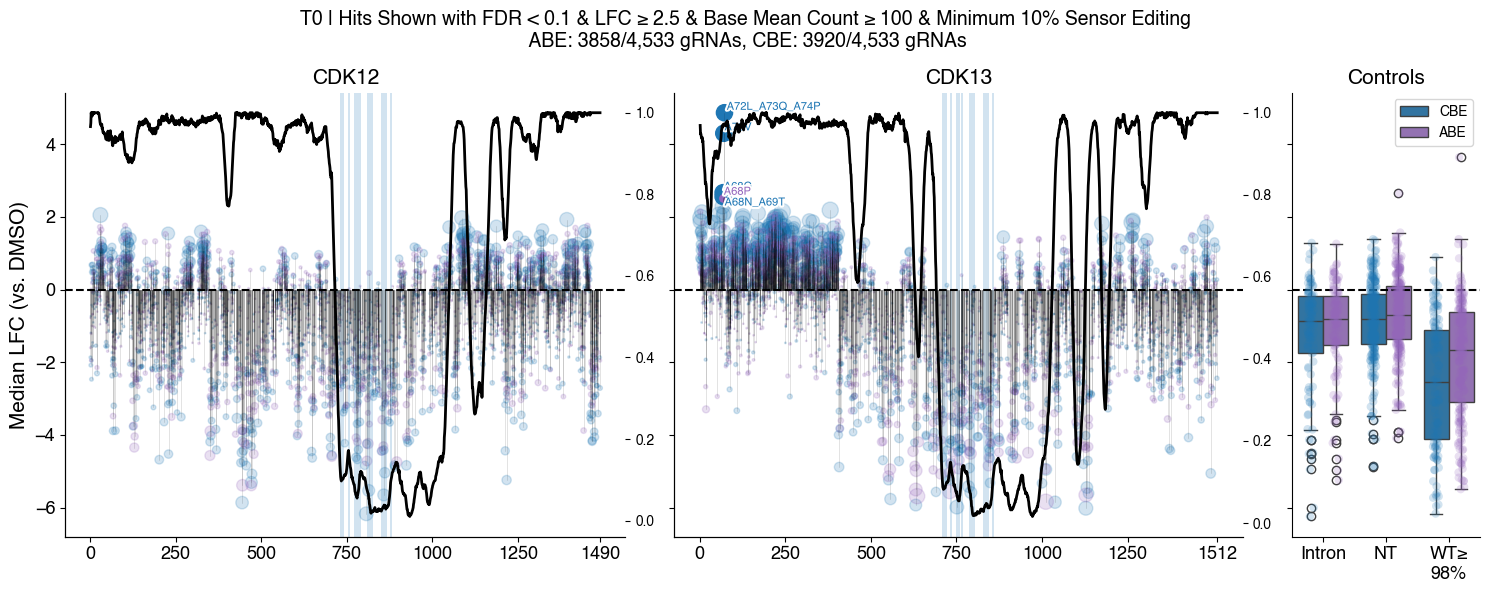

In [867]:
n = 'T0' #'CDK12-IN-2' 'HQ461'
true_name = n
condition_of_interest_CBE = f'CBE_{n}'
condition_of_interest_ABE = f'ABE_{n}'

min_base_counts = 100
WT_cutoff_main = 90
WT_cutoff_ctrl = 98
FDR_cutoff = 0.1
LFC_cutoff = 2.5

fig1 = subpool2_plotter(m_CBE, m_ABE, targ_CBE, targ_ABE, condition_of_interest_CBE, condition_of_interest_ABE, true_name, min_base_counts, WT_cutoff_main, WT_cutoff_ctrl, FDR_cutoff, LFC_cutoff, plot_ABE=True, plot_CBE=True)
#fig1.savefig(f'../../figures/sub2_disorder.png', dpi=400, transparent=True)

In [887]:
gene = 'CDK13'
edits = sav_dict[gene].rename(columns = {'HGVSp_new':'HGVSp_VEP'})

#can limit it to only SNPs for direct comparison; essentially the same result
#inc_edits = list(db_dict[gene]['HGVSp_VEP'])

mis = edits[edits['Var_Type']=='Missense']

#mis_abe = mis[(mis['Editor']=='ABE') & (mis['HGVSp_VEP'].isin(inc_edits))].reset_index(drop=True)
#mis_cbe = mis[(mis['Editor']=='CBE') & (mis['HGVSp_VEP'].isin(inc_edits))].reset_index(drop=True)
mis_abe = mis[(mis['Editor']=='ABE')].reset_index(drop=True)
mis_cbe = mis[(mis['Editor']=='CBE')].reset_index(drop=True)

if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
    lfc_info_abe = ABE1[ABE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_T0']]
    lfc_info_cbe = CBE1[CBE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_T0']]
elif gene in ['CDK12', 'CDK13']:
    lfc_info_abe = ABE2[ABE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_ABE_T0']].rename(columns = {'LFC_median_ABE_T0':'LFC_median_T0'})
    lfc_info_cbe = CBE2[CBE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_CBE_T0']].rename(columns = {'LFC_median_CBE_T0':'LFC_median_T0'})

merge_cbe = pd.merge(mis_cbe, lfc_info_cbe, on='gRNA_id')
merge_abe = pd.merge(mis_abe, lfc_info_abe, on='gRNA_id')


merge_cbe = merge_cbe[merge_cbe['%Reads']>=min_edit]
merge_abe = merge_abe[merge_abe['%Reads']>=min_edit]

dis1 = disorder_dict[gene]

merge_cbe2 = pd.merge(merge_cbe, dis1, on='Codon')
merge_abe2 = pd.merge(merge_abe, dis1, on='Codon')

PearsonRResult(statistic=0.4010654252850577, pvalue=7.564833770617038e-110)

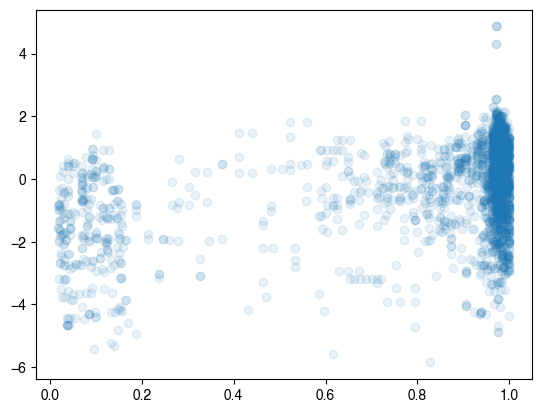

In [893]:
plt.scatter(merge_cbe2[' Disorder'], merge_cbe2['LFC_median_T0'], alpha=.1) 
scipy.stats.pearsonr(merge_cbe2[' Disorder'], merge_cbe2['LFC_median_T0'])

PearsonRResult(statistic=0.43524918740636537, pvalue=3.146168122764497e-143)

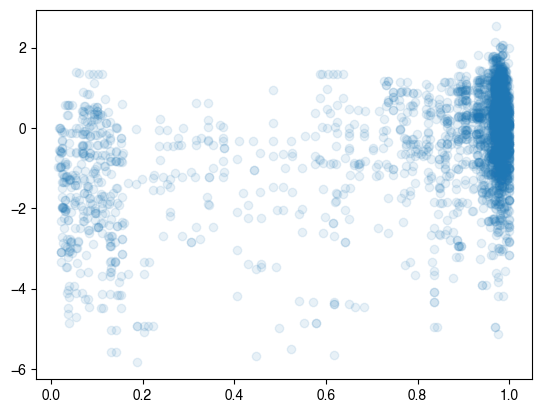

In [892]:
plt.scatter(merge_abe2[' Disorder'], merge_abe2['LFC_median_T0'], alpha=.1) 
scipy.stats.pearsonr(merge_abe2[' Disorder'], merge_abe2['LFC_median_T0'])

# Tfinal vs. Plasmid

In [778]:
def corr_maker2(gene, min_edit, min_base_counts):

    annots = db_dict[gene]
    edits = sav_dict[gene].rename(columns = {'HGVSp_new':'HGVSp_VEP'})

    m1 = pd.merge(annots, edits, on='HGVSp_VEP')

    mis = m1[m1['Var_Type']=='Missense']
    mis_abe = mis[mis['Editor']=='ABE'].reset_index(drop=True)
    mis_cbe = mis[mis['Editor']=='CBE'].reset_index(drop=True)

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
        lfc_info_abe = ABE1[ABE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_DMSO']]
        lfc_info_cbe = CBE1[CBE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_DMSO']]
    elif gene in ['CDK12', 'CDK13']:
        lfc_info_abe = ABE2[ABE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_ABE_DMSO']].rename(columns = {'LFC_median_ABE_DMSO':'LFC_median_DMSO'})
        lfc_info_cbe = CBE2[CBE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_CBE_DMSO']].rename(columns = {'LFC_median_CBE_DMSO':'LFC_median_DMSO'})

    merge_cbe = pd.merge(mis_cbe, lfc_info_cbe, on='gRNA_id')
    merge_abe = pd.merge(mis_abe, lfc_info_abe, on='gRNA_id')

    merge_cbe = merge_cbe[merge_cbe['%Reads']>=min_edit]
    merge_abe = merge_abe[merge_abe['%Reads']>=min_edit]

    #-------correlations-------

    abe_pear_list = []
    abe_spear_list = []
    cbe_pear_list = []
    cbe_spear_list = []
    vep_name = []

    for i in comb_VEP_cons:
        
        try:
            cbe_spear = scipy.stats.spearmanr([float(i) for i in merge_cbe[i]], merge_cbe['LFC_median_DMSO']).statistic
            cbe_pear = scipy.stats.pearsonr([float(i) for i in merge_cbe[i]], merge_cbe['LFC_median_DMSO']).statistic

            abe_spear = scipy.stats.spearmanr([float(i) for i in merge_abe[i]], merge_abe['LFC_median_DMSO']).statistic
            abe_pear = scipy.stats.pearsonr([float(i) for i in merge_abe[i]], merge_abe['LFC_median_DMSO']).statistic

            vep_name.append(i)
            abe_pear_list.append(abe_pear)
            abe_spear_list.append(abe_spear)
            cbe_pear_list.append(cbe_pear)
            cbe_spear_list.append(cbe_spear)
            
        except:
            continue

    CBE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_pear_list,vep_name])))
    ABE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_pear_list,vep_name])))
    CBE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_spear_list,vep_name])))
    ABE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_spear_list,vep_name])))

    CBE_pear_df['Editor']='CBE'
    ABE_pear_df['Editor']='ABE'
    CBE_spear_df['Editor']='CBE'
    ABE_spear_df['Editor']='ABE'

    spearman_df = pd.concat((CBE_spear_df, ABE_spear_df))
    pearson_df = pd.concat((CBE_pear_df, ABE_pear_df))

    return pearson_df, spearman_df

In [779]:
def corr_disorder2(gene, min_edit, min_base_counts):
    edits = sav_dict[gene].rename(columns = {'HGVSp_new':'HGVSp_VEP'})

    mis = edits[edits['Var_Type']=='Missense']

    mis_abe = mis[mis['Editor']=='ABE'].reset_index(drop=True)
    mis_cbe = mis[mis['Editor']=='CBE'].reset_index(drop=True)

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
        lfc_info_abe = ABE1[ABE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_DMSO']]
        lfc_info_cbe = CBE1[CBE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_DMSO']]
    elif gene in ['CDK12', 'CDK13']:
        lfc_info_abe = ABE2[ABE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_ABE_DMSO']].rename(columns = {'LFC_median_ABE_DMSO':'LFC_median_DMSO'})
        lfc_info_cbe = CBE2[CBE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_CBE_DMSO']].rename(columns = {'LFC_median_CBE_DMSO':'LFC_median_DMSO'})

    merge_cbe = pd.merge(mis_cbe, lfc_info_cbe, on='gRNA_id')
    merge_abe = pd.merge(mis_abe, lfc_info_abe, on='gRNA_id')


    merge_cbe = merge_cbe[merge_cbe['%Reads']>=min_edit]
    merge_abe = merge_abe[merge_abe['%Reads']>=min_edit]

    dis1 = disorder_dict[gene]

    merge_cbe2 = pd.merge(merge_cbe, dis1, on='Codon')
    merge_abe2 = pd.merge(merge_abe, dis1, on='Codon')


    abe_pear_list = []
    abe_spear_list = []
    cbe_pear_list = []
    cbe_spear_list = []
    vep_name = []


    i = ' Disorder'
    cbe_spear = scipy.stats.spearmanr([float(i) for i in merge_cbe2[i]], merge_cbe2['LFC_median_DMSO']).statistic
    cbe_pear = scipy.stats.pearsonr([float(i) for i in merge_cbe2[i]], merge_cbe2['LFC_median_DMSO']).statistic

    abe_spear = scipy.stats.spearmanr([float(i) for i in merge_abe2[i]], merge_abe2['LFC_median_DMSO']).statistic
    abe_pear = scipy.stats.pearsonr([float(i) for i in merge_abe2[i]], merge_abe2['LFC_median_DMSO']).statistic

    vep_name.append(i)
    abe_pear_list.append(abe_pear)
    abe_spear_list.append(abe_spear)
    cbe_pear_list.append(cbe_pear)
    cbe_spear_list.append(cbe_spear)
            

    CBE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_pear_list,vep_name])))
    ABE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_pear_list,vep_name])))
    CBE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_spear_list,vep_name])))
    ABE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_spear_list,vep_name])))

    CBE_pear_df['Editor']='CBE'
    ABE_pear_df['Editor']='ABE'
    CBE_spear_df['Editor']='CBE'
    ABE_spear_df['Editor']='ABE'

    spearman_df = pd.concat((CBE_spear_df, ABE_spear_df))
    pearson_df = pd.concat((CBE_pear_df, ABE_pear_df))

    return spearman_df, pearson_df

In [784]:
ABE1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/ABE_subpool1_barcode_Plasmid_base.csv')
CBE1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CBE_subpool1_barcode_Plasmid_base.csv')

ABE2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_ABE_barcode_Plasmid_base.csv')
CBE2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_CBE_barcode_Plasmid_base.csv')

In [785]:

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']
min_edit = 20
min_base_counts = 100

pear_holder2 = []
spear_holder2 = []
for gene in genes:
    spearman_df, pearson_df = corr_disorder2(gene, min_edit, min_base_counts)
    pear_holder2.append(pearson_df)
    spear_holder2.append(spearman_df)

min_edit = 20
min_base_counts = 100

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

pear_holder = []
spear_holder = []
for gene in genes:

    pear, spear = corr_maker2(gene, min_edit, min_base_counts)
    pear_holder.append(pear)
    spear_holder.append(spear)

In [786]:
a = pd.concat(spear_holder).reset_index(drop=True)
bb = pd.concat(spear_holder2).reset_index(drop=True)

aa = pd.concat((a, bb))
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)


aa.loc[aa['VEP']==' Disorder', 'Correlation'] = -np.asarray(aa.loc[aa['VEP']==' Disorder', 'Correlation'])
aa.loc[aa['VEP']==' Disorder']


u, c = np.unique(aa['VEP'], return_counts=True)
d1 = pd.DataFrame(dict(zip(['u','c'], [u,c])))
no_full_stats = list(d1[d1['c']!=12]['u'])

aa = aa[~aa['VEP'].isin(no_full_stats)].reset_index(drop=True)
aa = aa[aa['VEP'].isin(flat_veps)].reset_index(drop=True)
#aa['Name'] = 


def categorize_vep(vep):
    for category, veps in vep_categories.items():
        if vep in veps:
            return category
    return 'other'

aa['VEP_category'] = aa['VEP'].apply(categorize_vep)
aa['Name'] = [vep_names[i] for i in aa['VEP']]

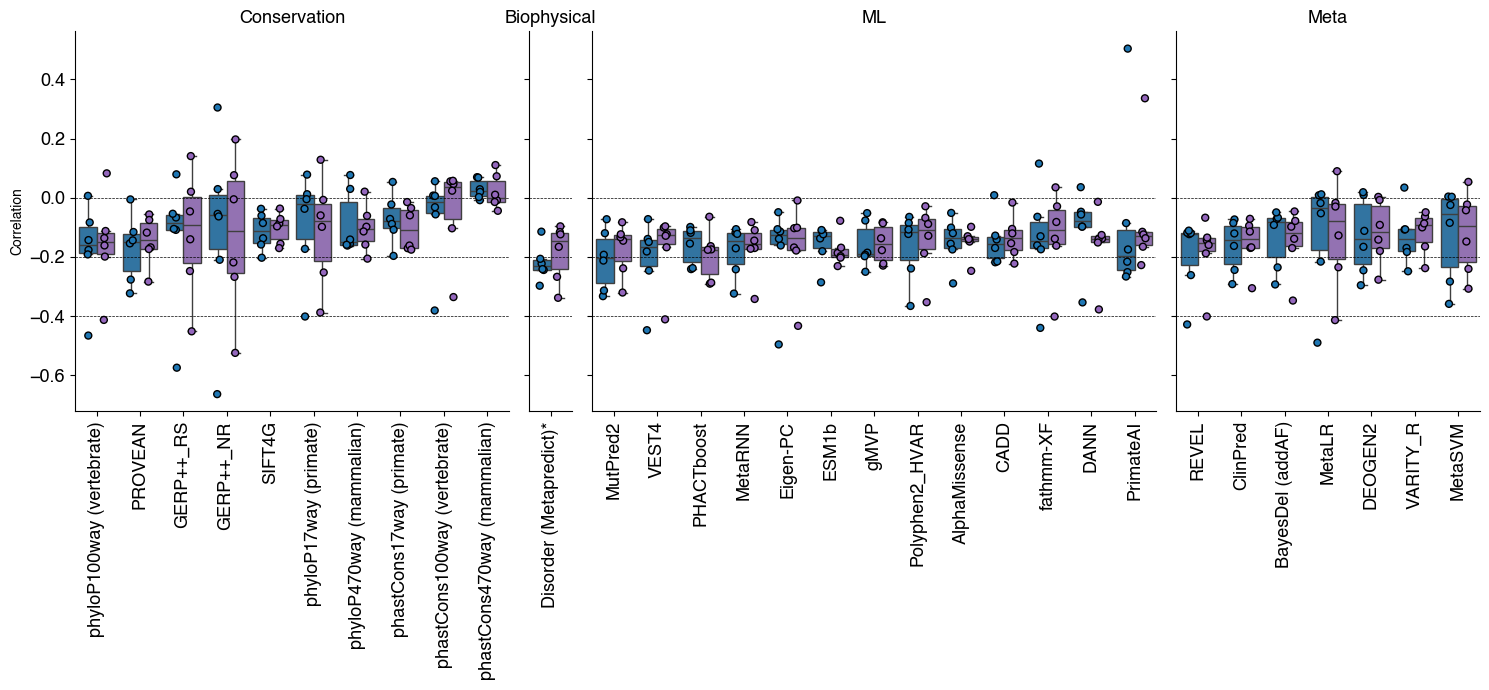

In [787]:
list(vep_categories.keys())

o = ['Conservation', 'Biophysical', 'ML', 'Meta']

fig, ax = plt.subplots(1,4,figsize=(15,7), width_ratios=[120, 12, 156, 84], sharey=True)

for i, val in enumerate(o):
    g = aa[aa['VEP_category']==val].reset_index()
    vep_order = g.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list() 

    sns.boxplot(data=g,x='VEP', y='Correlation',hue='Editor', showfliers=False, order=vep_order, ax=ax[i], palette=['tab:blue', 'tab:purple'], legend=False)
    sns.stripplot(data=g,x='VEP', y='Correlation',hue='Editor', order=vep_order, ax=ax[i], palette=['tab:blue', 'tab:purple'], edgecolor='black', linewidth=1, dodge=True, legend=False)

    ax[i].set_xticklabels([vep_names[i] for i in vep_order], rotation=90)
    ax[i].set_xlabel('')
    ax[i].axhline(0, linewidth=0.5, linestyle='dashed', color='black')
    ax[i].axhline(-0.2, linewidth=0.5, linestyle='dashed', color='black')
    ax[i].axhline(-0.4, linewidth=0.5, linestyle='dashed', color='black')
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].tick_params(axis='both', which='major', labelsize=13)
    ax[i].set_title(val, fontsize=13)
fig.tight_layout()

In [ ]:
scipy.stats.pearsonr(merge_cbe2['LFC_median_T0'], merge_cbe2[' Disorder']).s

PearsonRResult(statistic=0.20139081983131657, pvalue=2.151727565901353e-07)